# Phase 1: XLM-RoBERTa-Large with Linguistic Features

**Team Data Asgardians. Notebook 2 of 4 in the reproducibility pipeline.**

This notebook documents the first modeling phase. Training was carried out on Google Colab Pro with a dedicated GPU (NVIDIA T4). The stored outputs correspond to those runs and are preserved intentionally; re-executing the transformer cells requires a GPU and the official task data from `https://github.com/britishcouncil/bea2026st`.

## Purpose of this notebook

This notebook no longer attempts to compare many backbones or many strategies at once. It addresses a single central question:

**How much do linguistic features help to explain or improve difficulty prediction when using a single main model, `xlm-roberta-large`?**

We work with three levels of evidence, in this order:

1. **Feature diagnostics**: assess whether the linguistic variables carry signal of their own.
2. **Tabular baseline**: measure how much the features explain on their own.
3. **Main model**: a single `xlm-roberta-large` with features serialized into the input.

This keeps the workflow explicit and avoids the confusion of mixing many models, many experimental blocks, and redundant figures.

## Workflow

Run this notebook in the following order:

1. **Setup**
2. **Data loading and reference results**
3. **Simplified feature engineering**
4. **Feature analysis**
5. **Tabular model on features**
6. **XLM-RoBERTa-large with serialized features**
7. **Final comparison and conclusions**

### How to read the results

- If the features help neither on their own nor combined with the transformer, that is also a valid finding.
- If the features are informative as analysis but do not improve the transformer, the problem is probably not the features themselves but the way they are integrated.

### Note for Google Colab

The notebook is designed to run in parts. The transformer cell exposes a flag to either train from scratch or reuse an existing checkpoint.

## 0. Setup

In [1]:
0# ── Instalar dependencias y clonar repo (solo necesario en Colab) ──────────────
# Descomenta las siguientes líneas la primera vez que corras en Google Colab:
# !pip install -q transformers datasets accelerate sentencepiece nltk seaborn xgboost
# !git clone https://github.com/AdrianPinedaSanchez/british_council_test.git

import gc
import math
import re
import warnings
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/british_council_test"),
        Path("/content"),
    ]
    for candidate in candidates:
        if (candidate / "bea2026st").exists():
            return candidate
    raise FileNotFoundError("No encontre una carpeta 'bea2026st'. Ajusta PROJECT_ROOT manualmente.")

PROJECT_ROOT = find_project_root()
BEA_DIR = PROJECT_ROOT / "bea2026st"
DATA_DIR = BEA_DIR / "data"
MODELS_DIR = BEA_DIR / "models"
RESULTS_DIR = BEA_DIR / "results"

SEED = 42
set_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.cuda.empty_cache()

# ── Hiperparámetros del transformer (Strategy A: features serializadas) ────────
# Pensados para Colab con GPU T4/A100. En CPU solo se usa el checkpoint existente.
RUN_TRANSFORMER_TRAINING = False   # Cambiar a True en Colab con GPU
MAX_LENGTH = 192
NUM_EPOCHS = 5                     # 5 épocas para que converja bien
TRAIN_BATCH_SIZE = 16              # GPU T4: 16 cabe en 15GB VRAM con fp16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2               # effective batch = 32
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

# ── Hiperparámetros del método híbrido (embeddings + XGBoost) ──────────────────
EMB_BATCH_SIZE = 64 if DEVICE == "cuda" else 16   # batch para extraer embeddings
PCA_DIMS = 128

EXISTING_MODEL_DIR = MODELS_DIR / "exp7_open_xlmr_features_textual"
OUTPUT_MODEL_DIR = MODELS_DIR / "exp8_xlmr_large_features_colab"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DEVICE: {DEVICE}")
print(f"RUN_TRANSFORMER_TRAINING: {RUN_TRANSFORMER_TRAINING}")
print(f"EMB_BATCH_SIZE: {EMB_BATCH_SIZE} | PCA_DIMS: {PCA_DIMS}")
print(f"Transformer: epochs={NUM_EPOCHS}, batch={TRAIN_BATCH_SIZE}, accum={GRAD_ACCUM_STEPS}, lr={LEARNING_RATE}")

c:\Users\adria\miniconda3\envs\baseline_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: c:\Users\adria\Documents\Doctorado\british_council
DEVICE: cpu
RUN_TRANSFORMER_TRAINING: False
EMB_BATCH_SIZE: 16 | PCA_DIMS: 128
Transformer: epochs=5, batch=16, accum=2, lr=1e-05


## 1. Data loading and reference results

This section fixes the point of comparison. The official baseline remains the external reference.

We do not train several base models here. The reference is used only to answer whether our features contribute anything or not.

In [2]:
L1_ORDER = ["es", "de", "cn"]

def load_split(split_name):
    frames = []
    for l1 in L1_ORDER:
        path = DATA_DIR / split_name / l1 / f"kvl_shared_task_{l1}_{split_name}.csv"
        frame = pd.read_csv(path)
        frame["split"] = split_name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

train_df = load_split("train")
dev_df = load_split("dev")

baseline_path = RESULTS_DIR / "results_summary_dev.csv"
if baseline_path.exists():
    baseline_results_all = pd.read_csv(baseline_path)
    if "track" in baseline_results_all.columns:
        baseline_results_all["track"] = baseline_results_all["track"].astype(str).str.lower()
    else:
        baseline_results_all["track"] = "unknown"

    baseline_results_all = baseline_results_all[["track", "L1", "rmse", "pearson"]].copy()
    baseline_results_all["model_label"] = "Official baseline"

    baseline_results_open = baseline_results_all[baseline_results_all["track"] == "open"].copy()
    baseline_results_closed = baseline_results_all[baseline_results_all["track"].isin(["closed", "close"])].copy()
else:
    baseline_results_open = pd.DataFrame({
        "track": ["open"] * 3,
        "L1": ["es", "de", "cn"],
        "rmse": [1.2060841866514214, 1.1486658737533606, 1.0213964262014545],
        "pearson": [0.7873063484454521, 0.800390009388446, 0.8042396463775818],
        "model_label": ["Official baseline"] * 3,
    })
    baseline_results_closed = pd.DataFrame({
        "track": ["closed"] * 3,
        "L1": ["es", "de", "cn"],
        "rmse": [np.nan, np.nan, np.nan],
        "pearson": [np.nan, np.nan, np.nan],
        "model_label": ["Official baseline"] * 3,
    })
    baseline_results_all = pd.concat([baseline_results_open, baseline_results_closed], ignore_index=True)

# Mantiene compatibilidad con el resto del notebook: baseline_results = open track
baseline_results = baseline_results_open[["L1", "rmse", "pearson", "model_label"]].copy()

print(f"Train shape: {train_df.shape}")
print(f"Dev shape:   {dev_df.shape}")
print(f"Baseline open rows:   {len(baseline_results_open)}")
print(f"Baseline closed rows: {len(baseline_results_closed)}")

display(train_df.head())
display(baseline_results_open.round(4))
display(baseline_results_closed.round(4))

Train shape: (18273, 9)
Dev shape:   (2031, 9)
Baseline open rows:   3
Baseline closed rows: 3


,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split
0,1,es,span,noun,s___,lapso,El eclipse solar fue visible durante un breve ...,-3.264099,train
1,2,es,radically,adverb,r________,fundamentalmente,Los métodos nuevos son fundamentalmente difere...,-1.871782,train
2,3,es,supermarket,noun,s__________,supermercado,Vamos al supermercado y compramos todo lo que ...,2.733109,train
3,4,es,airplane,noun,a_______,avión,El avión despegó tres horas tarde.,0.054737,train
4,5,es,trying,adjective,t_____,difícil,"Es un tiempo muy difícil, sin ninguna duda.",-4.086776,train


,track,L1,rmse,pearson,model_label
3,open,es,1.2061,0.7873,Official baseline
4,open,de,1.1487,0.8004,Official baseline
5,open,cn,1.0214,0.8042,Official baseline


,track,L1,rmse,pearson,model_label
0,closed,cn,1.1748,0.7355,Official baseline
1,closed,de,1.3283,0.7530,Official baseline
2,closed,es,1.3569,0.7484,Official baseline


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18273 entries, 0 to 18272
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         18273 non-null  int64  
 1   L1              18273 non-null  str    
 2   en_target_word  18273 non-null  str    
 3   en_target_pos   18273 non-null  str    
 4   en_target_clue  18273 non-null  str    
 5   L1_source_word  18273 non-null  str    
 6   L1_context      18273 non-null  str    
 7   GLMM_score      18273 non-null  float64
 8   split           18273 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 2.9 MB


In [4]:
train_df.head(10)

,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split
0,1,es,span,noun,s___,lapso,El eclipse solar fue visible durante un breve ...,-3.264099,train
1,2,es,radically,adverb,r________,fundamentalmente,Los métodos nuevos son fundamentalmente difere...,-1.871782,train
2,3,es,supermarket,noun,s__________,supermercado,Vamos al supermercado y compramos todo lo que ...,2.733109,train
3,4,es,airplane,noun,a_______,avión,El avión despegó tres horas tarde.,0.054737,train
4,5,es,trying,adjective,t_____,difícil,"Es un tiempo muy difícil, sin ninguna duda.",-4.086776,train
5,6,es,racing,noun,r_____,carreras,¿Te puedes creer que se ha comprado un coche d...,-0.071782,train
6,7,es,sleep,verb,s____,dormir,Es importante dormir bien si estás enfermo.,3.682800,train
7,8,es,military,noun,m_______,ejército,El ejército no parecía nada contento con los c...,-0.086130,train
8,9,es,capacity,noun,c_______,cabida,La sala da cabida a dos mil personas.,-1.726756,train
9,10,es,cane,noun,c___,bastón,Siempre veras a mi abuelo caminando con su bastón,-0.837535,train


In [5]:
dev_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2031 entries, 0 to 2030
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         2031 non-null   int64  
 1   L1              2031 non-null   str    
 2   en_target_word  2031 non-null   str    
 3   en_target_pos   2031 non-null   str    
 4   en_target_clue  2031 non-null   str    
 5   L1_source_word  2031 non-null   str    
 6   L1_context      2031 non-null   str    
 7   GLMM_score      2031 non-null   float64
 8   split           2031 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 326.9 KB


In [6]:
dev_df.head(10)

,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split
0,6092,es,bizarre,adjective,b______,extraña,Esta situación es muy extraña y no entiendo nada.,-0.900104,dev
1,6093,es,proof,noun,p____,evidencia,¿Nos puede enseñar evidencia de su identidad p...,-1.055006,dev
2,6094,es,recent,adjective,r_____,nuevo,El descubrimiento nuevo de los restos de una i...,-0.517317,dev
3,6095,es,assistant,noun,a________,ayudante,Trabaja como ayudante al Doctor González en el...,-0.145263,dev
4,6096,es,spring,noun,s_____,primavera,La primavera es mi estación preferida.,2.668638,dev
5,6097,es,nutrition,noun,n________,alimentación,La buena alimentación es clave para llevar una...,0.571423,dev
6,6098,es,milk,noun,m___,leche,Me encanta el chocolate con leche.,3.962283,dev
7,6099,es,attempted,adjective,a________,pretendido,El el año 1970 hubo un pretendido golpe de est...,-2.275116,dev
8,6100,es,floor,noun,f____,suelo,No queda asientos así que tendréis que sentaro...,2.304040,dev
9,6101,es,softness,noun,s_______,suavidad,La suavidad de las sábanas era muy agradable y...,-0.197926,dev


## 2. Simplified feature engineering

We keep a short set of features that are reasonable, interpretable, and easy to justify:

- word length
- clue difficulty
- polysemy
- homonymy
- consonant clusters
- L1-weighted rhoticity
- number of phonemes
- silent letters
- L1-specific difficult graphemes
- heuristic syntactic difficulty
- approximate WordNet frequency

The goal is not to fill the notebook with features. The goal is to have a short block that answers one question: **what additional signal do these variables carry?**

In [7]:
"""
Feature Engineering para predicción de dificultad léxica (GLMM_score).
Sin pesos arbitrarios — todas las features son crudas o basadas en datos.
Las interacciones con L1 las aprende el modelo, no se hardcodean.

Requiere: nltk, numpy, pandas, regex (re)
Datasets: train_df, dev_df con columnas:
  item_id, L1, en_target_word, en_target_pos, en_target_clue,
  L1_source_word, L1_context, GLMM_score, split
"""

import re
import math
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import nltk
from nltk.corpus import cmudict, wordnet as wn

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────
# 0. NLTK SETUP
# ─────────────────────────────────────────────────────────
for pkg in ["wordnet", "omw-1.4", "cmudict"]:
    nltk.download(pkg, quiet=True)

CMU_DICT = cmudict.dict()
POS_MAP = {
    "noun": wn.NOUN,
    "verb": wn.VERB,
    "adjective": wn.ADJ,
    "adverb": wn.ADV,
}

# ─────────────────────────────────────────────────────────
# 1. INVENTARIOS FONOLÓGICOS POR L1 (basado en datos, no arbitrario)
#    Fuente: PHOIBLE / inventarios estándar simplificados.
#    Fonemas IPA que NO existen en el L1 → difíciles para ese hablante.
# ─────────────────────────────────────────────────────────
# Mapeo de grafemas ingleses a fonemas ARPAbet aproximados
GRAPHEME_TO_ARPABET = {
    "th": ["TH", "DH"],     # θ, ð
    "sh": ["SH"],            # ʃ
    "ch": ["CH"],            # tʃ
    "wh": ["W", "HH"],       # hw
    "zh": ["ZH"],            # ʒ
    "ng": ["NG"],            # ŋ
    "r":  ["R"],              # ɹ
    "v":  ["V"],              # v
    "z":  ["Z"],              # z
}

# Fonemas ARPAbet ausentes en cada L1 (basado en inventarios fonológicos reales)
# es: español no tiene /θ, ð, ʃ, ʒ, h/ como en inglés; /v/ es alófono
# de: alemán no tiene /θ, ð/; tiene /ʃ, ʒ, v, z/
# cn: mandarín no tiene /θ, ð, ʃ(parcial), ʒ, ɹ, v, z, ŋ(final)/
L1_ABSENT_PHONEMES = {
    "es": {"TH", "DH", "SH", "ZH", "V", "Z"},
    "de": {"TH", "DH"},
    "cn": {"TH", "DH", "SH", "ZH", "R", "V", "Z", "NG"},
}

# ─────────────────────────────────────────────────────────
# 2. CACHED LOOKUPS
# ─────────────────────────────────────────────────────────
@lru_cache(maxsize=None)
def get_synsets(word):
    return wn.synsets(str(word).lower(), lang="eng")


@lru_cache(maxsize=None)
def get_pronunciation(word):
    """Retorna la primera pronunciación CMU o lista vacía."""
    return CMU_DICT.get(str(word).lower(), [[]])[0]


# ─────────────────────────────────────────────────────────
# 3. FEATURE FUNCTIONS — WORD-LEVEL
# ─────────────────────────────────────────────────────────

# A1. word_length
def word_length(word):
    return len(str(word))


# A2-A3. clue_blanks y clue_ratio
def clue_blanks(clue):
    return str(clue).count("_")


# A4. polysemy_pos — número de synsets filtrado por POS
def polysemy_pos(word, pos):
    wn_pos = POS_MAP.get(str(pos).lower())
    if wn_pos is None:
        return len(get_synsets(word))
    return len(wn.synsets(str(word).lower(), pos=wn_pos, lang="eng"))


# A5. is_homonym — si tiene synsets en más de un POS
def is_homonym(word):
    synsets = get_synsets(word)
    return int(len({s.pos() for s in synsets}) > 1)


# A6. n_consonant_clusters
def consonant_cluster_count(word):
    return len(re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower()))


# A7. r_count (CRUDO — sin peso por L1; la interacción la hace el modelo)
def r_count(word):
    pron = get_pronunciation(word)
    if pron:
        return sum(1 for p in pron if p.startswith("R"))
    return str(word).lower().count("r")


# A8. n_phonemes
def phoneme_count(word):
    pron = get_pronunciation(word)
    if pron:
        return len(pron)
    # Fallback: cuenta vocales como proxy de sílabas × 2.5 (mejor que len//2)
    vowels = len(re.findall(r"[aeiouy]+", str(word).lower()))
    return max(vowels * 2, 1)


# A9. silent_letters
def silent_letter_count(word):
    return max(len(str(word)) - phoneme_count(word), 0)


# A10. difficult_phonemes — basado en inventario fonológico real del L1
#      Cuenta fonemas en la pronunciación CMU que NO existen en el L1.
def difficult_phoneme_count(word, l1):
    """Cuenta fonemas de la palabra ausentes en el inventario del L1."""
    pron = get_pronunciation(word)
    absent = L1_ABSENT_PHONEMES.get(l1, set())
    if not pron or not absent:
        return 0
    # Limpiar stress markers (AH0 → AH)
    clean = [re.sub(r"\d", "", p) for p in pron]
    return sum(1 for p in clean if p in absent)


# A11. word_frequency (WordNet — log1p de conteo de lemmas)
def wordnet_frequency(word):
    total = 0
    for synset in get_synsets(word):
        for lemma in synset.lemmas():
            if lemma.name().lower() == str(word).lower():
                total += lemma.count()
    return math.log1p(total)


# ─────────────────────────────────────────────────────────
# 4. FEATURE FUNCTIONS — EXTENDED / CROSS-LINGUAL
# ─────────────────────────────────────────────────────────

# B1. polysemy_all — synsets totales sin filtrar por POS
def polysemy_all(word):
    return len(get_synsets(word))


# B2. homonym_pos_count — cuántos POS distintos tiene
def homonym_pos_count(word):
    synsets = get_synsets(word)
    return len({s.pos() for s in synsets})


# B3. max_cluster_length — longitud del cluster consonántico más largo
def max_cluster_length(word):
    clusters = re.findall(r"[bcdfghjklmnpqrstvwxyz]{2,}", str(word).lower())
    return max((len(c) for c in clusters), default=0)


# B4. has_r — binario
def has_r(word):
    return int("r" in str(word).lower())


# B5. spelling_phoneme_ratio — qué tan "irregular" es la ortografía
def spelling_phoneme_ratio(word):
    n_ph = phoneme_count(word)
    return len(str(word)) / max(n_ph, 1)


# B6-B7. unfamiliar_letters / has_unfamiliar
#   Letras inglesas raras para cada L1 (basado en alfabeto del L1)
L1_UNFAMILIAR_LETTERS = {
    "es": set("wk"),                     # w y k son raras en español
    "de": set(),                          # alemán usa el mismo alfabeto
    "cn": set("abcdefghijklmnopqrstuvwxyz"),  # todos son "extraños" para pinyin-nativo
}
# Para cn ajustamos: pinyin usa a-z, así que realmente ninguna letra es
# "desconocida" en sentido estricto. Mejor medir letras fuera del pinyin común.
# Pinyin no usa: v (excepto ü notación)
L1_UNFAMILIAR_LETTERS["cn"] = set()  # Mejor no inventar; dejamos vacío


def unfamiliar_letter_count(word, l1):
    letters = L1_UNFAMILIAR_LETTERS.get(l1, set())
    return sum(1 for ch in str(word).lower() if ch in letters)


def has_unfamiliar(word, l1):
    return int(unfamiliar_letter_count(word, l1) > 0)


# B8. cosine_dist_l1_en — distancia ortográfica entre L1_source_word y en_target_word
#   Usamos character n-gram overlap como proxy (no requiere embeddings)
def char_ngrams(word, n=2):
    """Genera set de character n-grams."""
    w = str(word).lower()
    return set(w[i:i+n] for i in range(len(w) - n + 1)) if len(w) >= n else {w}


def char_ngram_distance(word1, word2, n=2):
    """1 - Jaccard similarity de character bigrams. Rango [0, 1]."""
    s1 = char_ngrams(str(word1), n)
    s2 = char_ngrams(str(word2), n)
    if not s1 and not s2:
        return 0.0
    intersection = len(s1 & s2)
    union = len(s1 | s2)
    return 1.0 - (intersection / union) if union > 0 else 1.0


# B9. levenshtein_dist — distancia de edición normalizada
def levenshtein(s1, s2):
    """Levenshtein distance estándar."""
    s1, s2 = str(s1).lower(), str(s2).lower()
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    prev_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        curr_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = prev_row[j + 1] + 1
            deletions = curr_row[j] + 1
            substitutions = prev_row[j] + (c1 != c2)
            curr_row.append(min(insertions, deletions, substitutions))
        prev_row = curr_row
    return prev_row[-1]


def normalized_levenshtein(word1, word2):
    """Levenshtein normalizado por la longitud máxima. Rango [0, 1]."""
    w1, w2 = str(word1), str(word2)
    max_len = max(len(w1), len(w2))
    if max_len == 0:
        return 0.0
    return levenshtein(w1, w2) / max_len


# B10. morphological_complexity — proxy basado en afijos comunes del inglés
PREFIXES = ["un", "re", "in", "im", "ir", "il", "dis", "en", "em",
            "non", "pre", "mis", "over", "under", "out", "sub", "super"]
SUFFIXES = ["ing", "tion", "sion", "ment", "ness", "able", "ible", "ful",
            "less", "ous", "ive", "al", "ly", "er", "est", "ed", "es", "s"]


def morphological_complexity(word):
    """Cuenta de afijos detectados como proxy de complejidad morfológica."""
    w = str(word).lower()
    count = 0
    for p in PREFIXES:
        if w.startswith(p) and len(w) > len(p) + 2:
            count += 1
            break  # máximo un prefijo
    for s in sorted(SUFFIXES, key=len, reverse=True):
        if w.endswith(s) and len(w) > len(s) + 2:
            count += 1
            break  # máximo un sufijo
    return count


# B11. difficult_phoneme_ratio
def difficult_phoneme_ratio(word, l1):
    n_ph = phoneme_count(word)
    if n_ph == 0:
        return 0.0
    return difficult_phoneme_count(word, l1) / n_ph


# B12. final_cluster_size — tamaño del cluster consonántico final
def final_cluster_size(word):
    """Longitud del cluster consonántico al final de la palabra."""
    match = re.search(r"[bcdfghjklmnpqrstvwxyz]+$", str(word).lower())
    return len(match.group()) if match else 0


# ─────────────────────────────────────────────────────────
# 5. POS ENCODING (reemplaza syntactic_difficulty manual)
# ─────────────────────────────────────────────────────────
# En vez de asignar un peso manual por L1×POS, creamos dummies
# para POS y L1. El modelo aprende la interacción.


# ─────────────────────────────────────────────────────────
# 6. PIPELINE PRINCIPAL: add_features()
# ─────────────────────────────────────────────────────────
def add_features(df):
    """
    Construye TODAS las features lingüísticas sin pesos arbitrarios.
    Input:  DataFrame con columnas base del dataset.
    Output: DataFrame con todas las features añadidas.
    """
    data = df.copy()

    # --- Features de la palabra ---
    data["word_length"] = data["en_target_word"].astype(str).str.len()
    data["clue_blanks"] = data["en_target_clue"].astype(str).str.count("_")
    data["clue_ratio"] = data["clue_blanks"] / data["word_length"].clip(lower=1)

    data["polysemy_pos"] = data.apply(
        lambda r: polysemy_pos(r["en_target_word"], r["en_target_pos"]), axis=1
    )
    data["is_homonym"] = data["en_target_word"].apply(is_homonym)
    data["n_consonant_clusters"] = data["en_target_word"].apply(consonant_cluster_count)

    # r_count CRUDO — sin multiplicar por peso manual
    data["r_count"] = data["en_target_word"].apply(r_count)
    data["has_r"] = data["en_target_word"].apply(has_r)

    data["n_phonemes"] = data["en_target_word"].apply(phoneme_count)
    data["silent_letters"] = data["en_target_word"].apply(silent_letter_count)

    # difficult_phonemes basado en inventario fonológico real
    data["difficult_phonemes"] = data.apply(
        lambda r: difficult_phoneme_count(r["en_target_word"], r["L1"]), axis=1
    )
    data["difficult_phoneme_ratio"] = data.apply(
        lambda r: difficult_phoneme_ratio(r["en_target_word"], r["L1"]), axis=1
    )

    data["word_frequency"] = data["en_target_word"].apply(wordnet_frequency)

    # --- Features extendidas / cross-lingual ---
    data["polysemy_all"] = data["en_target_word"].apply(polysemy_all)
    data["homonym_pos_count"] = data["en_target_word"].apply(homonym_pos_count)
    data["max_cluster_length"] = data["en_target_word"].apply(max_cluster_length)
    data["spelling_phoneme_ratio"] = data["en_target_word"].apply(spelling_phoneme_ratio)

    data["unfamiliar_letters"] = data.apply(
        lambda r: unfamiliar_letter_count(r["en_target_word"], r["L1"]), axis=1
    )
    data["has_unfamiliar"] = data.apply(
        lambda r: has_unfamiliar(r["en_target_word"], r["L1"]), axis=1
    )

    # Distancia ortográfica L1 ↔ EN
    data["cosine_dist_l1_en"] = data.apply(
        lambda r: char_ngram_distance(r["L1_source_word"], r["en_target_word"]), axis=1
    )
    data["levenshtein_dist"] = data.apply(
        lambda r: normalized_levenshtein(r["L1_source_word"], r["en_target_word"]), axis=1
    )

    data["morphological_complexity"] = data["en_target_word"].apply(morphological_complexity)
    data["final_cluster_size"] = data["en_target_word"].apply(final_cluster_size)

    # --- Reemplazo de syntactic_difficulty: POS como dummies ---
    pos_dummies = pd.get_dummies(
        data["en_target_pos"].astype(str).str.lower(), prefix="pos"
    ).astype(int)
    data = pd.concat([data, pos_dummies], axis=1)

    # --- L1 como dummies (para interacciones en modelos lineales) ---
    l1_dummies = pd.get_dummies(data["L1"], prefix="l1").astype(int)
    data = pd.concat([data, l1_dummies], axis=1)

    return data


# ─────────────────────────────────────────────────────────
# 7. LISTA DE FEATURES PARA MODELADO
# ─────────────────────────────────────────────────────────

# Features numéricas (para RF / XGBoost que manejan interacciones solos)
FEATURE_COLS_TREE = [
    "word_length",
    "clue_ratio",
    "polysemy_pos",
    "is_homonym",
    "n_consonant_clusters",
    "r_count",
    "has_r",
    "n_phonemes",
    "silent_letters",
    "difficult_phonemes",
    "difficult_phoneme_ratio",
    "word_frequency",
    "polysemy_all",
    "homonym_pos_count",
    "max_cluster_length",
    "spelling_phoneme_ratio",
    "unfamiliar_letters",
    "has_unfamiliar",
    "cosine_dist_l1_en",
    "levenshtein_dist",
    "morphological_complexity",
    "final_cluster_size",
]

# Para modelos lineales: incluir dummies de POS y L1
# (se generan dinámicamente, pero los nombres esperados son:)
POS_DUMMY_COLS = ["pos_adjective", "pos_adverb", "pos_noun", "pos_verb"]
L1_DUMMY_COLS = ["l1_cn", "l1_de", "l1_es"]

FEATURE_COLS_LINEAR = FEATURE_COLS_TREE + POS_DUMMY_COLS + L1_DUMMY_COLS


# ─────────────────────────────────────────────────────────
# 8. EJECUTAR Y GUARDAR CSVs
# ─────────────────────────────────────────────────────────
# Ajusta esta ruta a tu carpeta local:
FEATURES_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features"

# --- Aplicar features (asume train_df y dev_df ya existen en tu notebook) ---
train_feat = add_features(train_df)
dev_feat = add_features(dev_df)

# --- Guardar CSVs ---
import os
os.makedirs(FEATURES_DIR, exist_ok=True)

train_feat.to_csv(os.path.join(FEATURES_DIR, "train_features.csv"), index=False)
dev_feat.to_csv(os.path.join(FEATURES_DIR, "dev_features.csv"), index=False)

print(f"train_features.csv guardado: {train_feat.shape}")
print(f"dev_features.csv guardado:   {dev_feat.shape}")
print(f"Ruta: {FEATURES_DIR}")
print(f"\n{len(FEATURE_COLS_TREE)} features numéricas + {len(POS_DUMMY_COLS + L1_DUMMY_COLS)} dummies = {len(FEATURE_COLS_LINEAR)} total")
print(f"\nPreview:")
display(train_feat[["L1", "en_target_word", "GLMM_score"] + FEATURE_COLS_TREE].head(10))

train_features.csv guardado: (18273, 44)
dev_features.csv guardado:   (2031, 43)
Ruta: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features

22 features numéricas + 7 dummies = 29 total

Preview:


,L1,en_target_word,GLMM_score,word_length,clue_ratio,polysemy_pos,is_homonym,n_consonant_clusters,r_count,has_r,...,polysemy_all,homonym_pos_count,max_cluster_length,spelling_phoneme_ratio,unfamiliar_letters,has_unfamiliar,cosine_dist_l1_en,levenshtein_dist,morphological_complexity,final_cluster_size
0,es,span,-3.264099,4,0.750000,6,1,1,0,0,...,7,2,2,1.000000,0,0,1.000000,0.800000,0,1
1,es,radically,-1.871782,9,0.888889,1,0,1,1,1,...,1,1,3,1.285714,0,0,0.947368,0.812500,1,3
2,es,supermarket,2.733109,11,0.909091,1,0,2,1,1,...,1,1,2,1.100000,1,1,0.666667,0.416667,1,1
3,es,airplane,0.054737,8,0.875000,1,0,1,1,1,...,1,1,3,1.333333,0,0,1.000000,0.750000,0,0
4,es,trying,-4.086776,6,0.833333,2,1,2,1,1,...,11,2,3,1.200000,0,0,1.000000,1.000000,1,2
5,es,racing,-0.071782,6,0.833333,1,1,1,1,1,...,5,2,2,1.200000,0,0,0.909091,0.875000,1,2
6,es,sleep,3.682800,5,0.800000,2,1,1,0,0,...,6,2,2,1.250000,0,0,1.000000,1.000000,0,1
7,es,military,-0.086130,8,0.875000,1,1,1,1,1,...,4,2,2,1.000000,0,0,0.923077,1.000000,0,2
8,es,capacity,-1.726756,8,0.875000,9,0,1,0,0,...,9,1,2,1.000000,0,0,0.909091,0.625000,0,2
9,es,cane,-0.837535,4,0.750000,3,1,0,0,0,...,4,2,0,1.333333,0,0,1.000000,0.833333,0,0


In [8]:
train_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 18273 entries, 0 to 18272
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_id                   18273 non-null  int64  
 1   L1                        18273 non-null  str    
 2   en_target_word            18273 non-null  str    
 3   en_target_pos             18273 non-null  str    
 4   en_target_clue            18273 non-null  str    
 5   L1_source_word            18273 non-null  str    
 6   L1_context                18273 non-null  str    
 7   GLMM_score                18273 non-null  float64
 8   split                     18273 non-null  str    
 9   word_length               18273 non-null  int64  
 10  clue_blanks               18273 non-null  int64  
 11  clue_ratio                18273 non-null  float64
 12  polysemy_pos              18273 non-null  int64  
 13  is_homonym                18273 non-null  int64  
 14  n_consonant_clust

CORRELACIÓN Pearson: cada feature vs GLMM_score


,global,cn,de,es
feature,,,,
clue_ratio,-0.381,-0.449,-0.353,-0.350
word_length,-0.369,-0.441,-0.344,-0.328
n_phonemes,-0.353,-0.437,-0.326,-0.304
word_frequency,0.314,0.488,0.233,0.237
cosine_dist_l1_en,-0.246,0.060,-0.352,-0.271
n_consonant_clusters,-0.243,-0.260,-0.220,-0.251
morphological_complexity,-0.237,-0.232,-0.236,-0.243
levenshtein_dist,-0.216,0.067,-0.368,-0.245
polysemy_pos,0.187,0.268,0.152,0.147


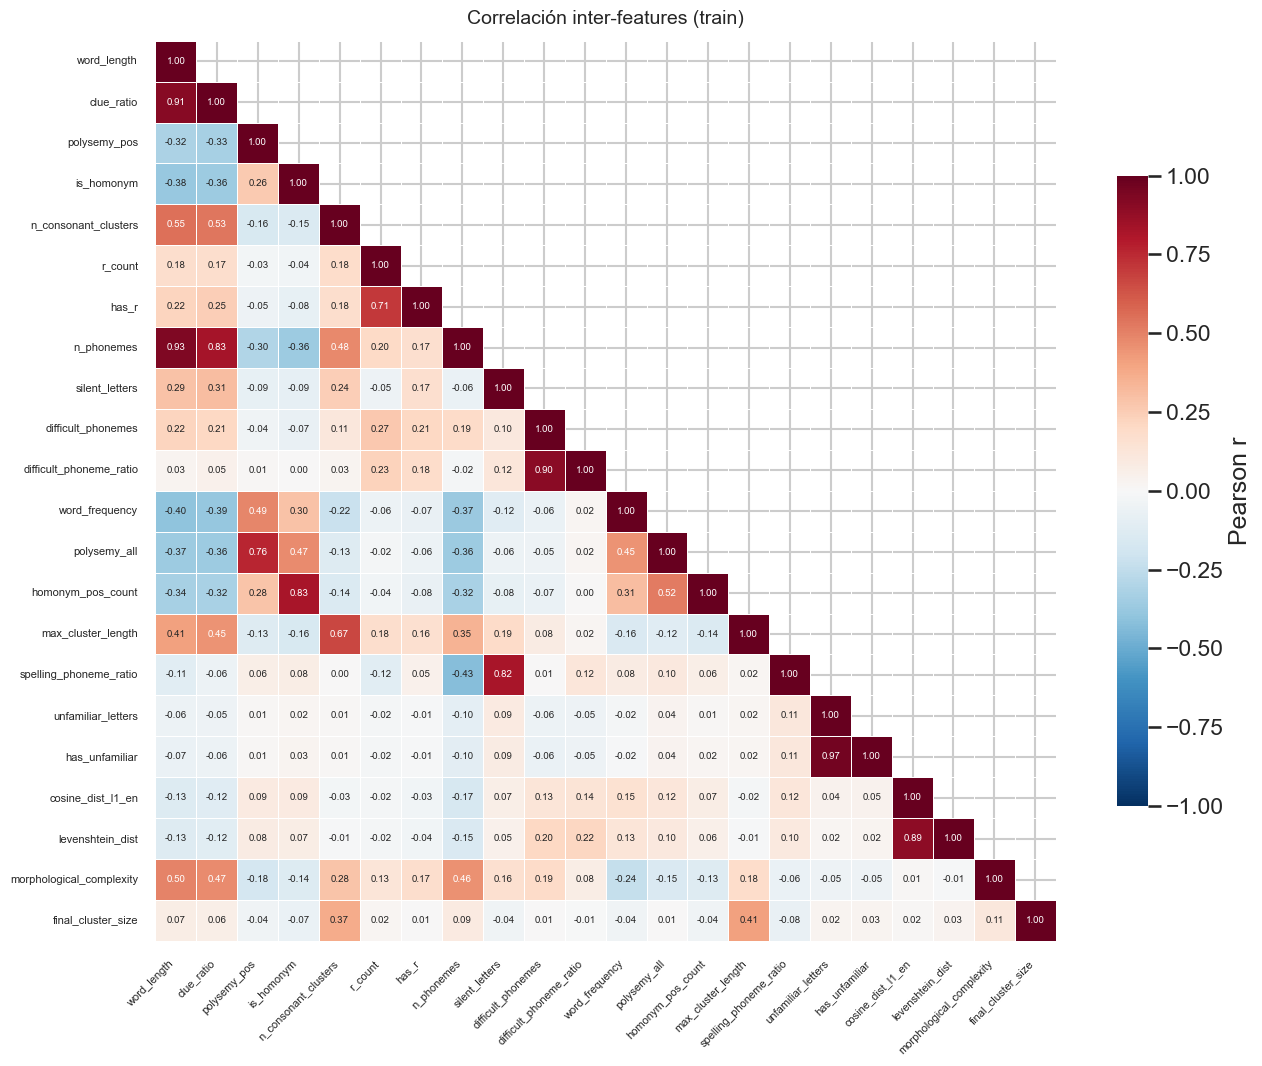

Heatmap guardado en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features/correlation_heatmap.png

⚠️  Pares con |r| > 0.85 (candidatos a eliminar uno):


,feature_1,feature_2,r
3,unfamiliar_letters,has_unfamiliar,0.966381
1,word_length,n_phonemes,0.932736
0,word_length,clue_ratio,0.909282
2,difficult_phonemes,difficult_phoneme_ratio,0.902121
4,cosine_dist_l1_en,levenshtein_dist,0.892286


In [9]:
"""
═══════════════════════════════════════════════════════════════
PASO 1.2 — Análisis de correlación
PASO 1.3 — Feature selection final
═══════════════════════════════════════════════════════════════
Pega esto en tu notebook DESPUÉS de la celda de feature engineering.
Requiere: train_feat (DataFrame con features ya aplicadas),
          FEATURE_COLS_TREE (lista de features numéricas).
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
 
# ─────────────────────────────────────────────────────────
# 1.2a  CORRELACIÓN DE CADA FEATURE vs GLMM_score
# ─────────────────────────────────────────────────────────
 
TARGET = "GLMM_score"
 
def correlation_table(df, features, target, groupby="L1"):
    """
    Calcula Pearson r de cada feature vs target,
    global y segmentado por L1.
    """
    rows = []
    groups = sorted(df[groupby].unique())
 
    for feat in features:
        row = {"feature": feat}
 
        # Global
        valid = df[[feat, target]].dropna()
        if len(valid) > 2 and valid[feat].std() > 0:
            row["global"] = pearsonr(valid[feat], valid[target])[0]
        else:
            row["global"] = np.nan
 
        # Por L1
        for g in groups:
            sub = df[df[groupby] == g][[feat, target]].dropna()
            if len(sub) > 2 and sub[feat].std() > 0:
                row[g] = pearsonr(sub[feat], sub[target])[0]
            else:
                row[g] = np.nan
 
        rows.append(row)
 
    result = pd.DataFrame(rows).set_index("feature")
    result["abs_global"] = result["global"].abs()
    return result.sort_values("abs_global", ascending=False)
 
 
corr_table = correlation_table(train_feat, FEATURE_COLS_TREE, TARGET)
 
print("=" * 65)
print("CORRELACIÓN Pearson: cada feature vs GLMM_score")
print("=" * 65)
display(
    corr_table[["global", "cn", "de", "es"]]
    .style
    .format("{:.3f}", na_rep="—")
    .background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4)
    .set_caption("Pearson r vs GLMM_score (train)")
)
 
# ─────────────────────────────────────────────────────────
# 1.2b  HEATMAP — CORRELACIÓN ENTRE FEATURES (multicolinealidad)
# ─────────────────────────────────────────────────────────
 
inter_corr = train_feat[FEATURE_COLS_TREE].corr(method="pearson")
 
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(inter_corr, dtype=bool), k=1)
sns.heatmap(
    inter_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Correlación inter-features (train)", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, "correlation_heatmap.png"), dpi=150)
plt.show()
print(f"Heatmap guardado en: {FEATURES_DIR}/correlation_heatmap.png")
 
# ─────────────────────────────────────────────────────────
# 1.2c  DETECTAR PARES ALTAMENTE CORRELACIONADOS
# ─────────────────────────────────────────────────────────
 
THRESHOLD_INTER = 0.85  # pares con |r| > 0.85 son redundantes
 
high_corr_pairs = []
for i in range(len(FEATURE_COLS_TREE)):
    for j in range(i + 1, len(FEATURE_COLS_TREE)):
        f1, f2 = FEATURE_COLS_TREE[i], FEATURE_COLS_TREE[j]
        r = inter_corr.loc[f1, f2]
        if abs(r) > THRESHOLD_INTER:
            high_corr_pairs.append({"feature_1": f1, "feature_2": f2, "r": r})
 
if high_corr_pairs:
    print(f"\n⚠️  Pares con |r| > {THRESHOLD_INTER} (candidatos a eliminar uno):")
    display(pd.DataFrame(high_corr_pairs).sort_values("r", key=abs, ascending=False))
else:
    print(f"\n✅ No hay pares con |r| > {THRESHOLD_INTER}")
 

FEATURE SELECTION — LOG DE DECISIONES
🗑  word_length                    — redundante con clue_ratio (inter r=0.909), |r_target|: word_length=0.369 < clue_ratio=0.381
🗑  n_phonemes                     — redundante con word_length (inter r=0.933), |r_target|: n_phonemes=0.353 < word_length=0.369
🗑  difficult_phoneme_ratio        — redundante con difficult_phonemes (inter r=0.902), |r_target|: difficult_phoneme_ratio=0.019 < difficult_phonemes=0.099
🗑  unfamiliar_letters             — redundante con has_unfamiliar (inter r=0.966), |r_target|: unfamiliar_letters=0.037 < has_unfamiliar=0.038
🗑  levenshtein_dist               — redundante con cosine_dist_l1_en (inter r=0.892), |r_target|: levenshtein_dist=0.216 < cosine_dist_l1_en=0.246
✅ clue_ratio                     — conservada (r_global=-0.381)
✅ polysemy_pos                   — conservada (r_global=0.187)
✅ is_homonym                     — conservada (r_global=0.137)
✅ n_consonant_clusters           — conservada (r_global=-0.243)
✅ r_c


Archivos guardados en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features
  - train_features_final.csv
  - dev_features_final.csv
  - FEATURE_COLS_FINAL.txt


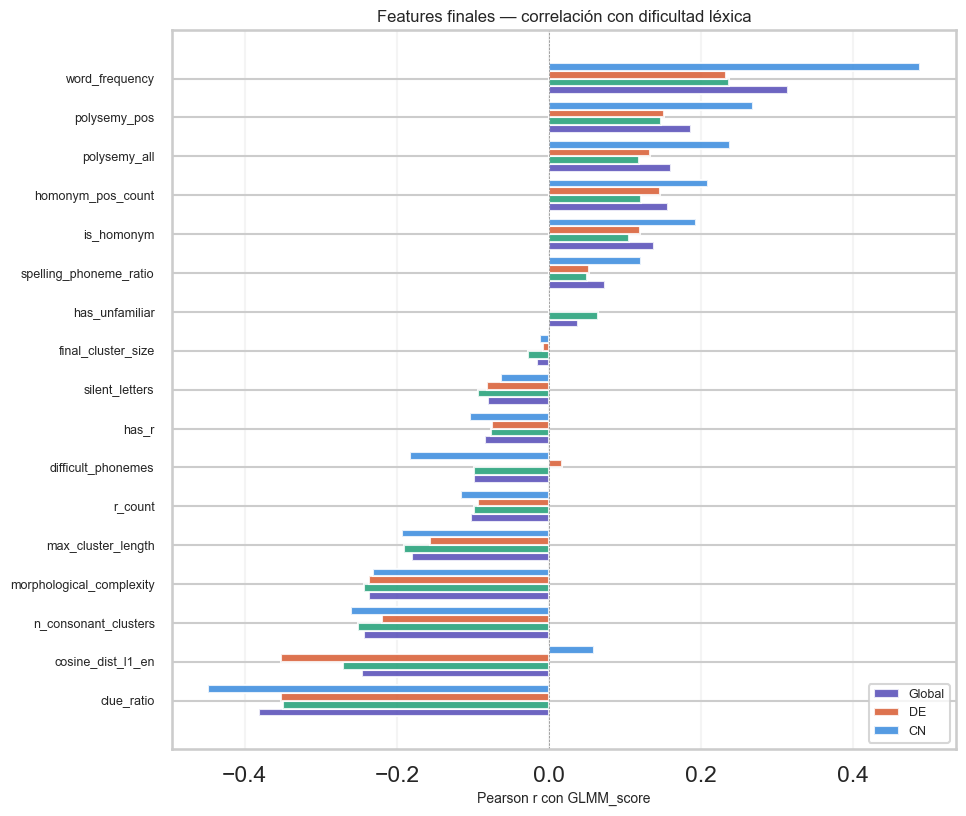


═════════════════════════════════════════════════════════════════
COPIAR ESTO PARA LA FASE 2:
═════════════════════════════════════════════════════════════════

FEATURE_COLS_FINAL = [
    "clue_ratio",
    "polysemy_pos",
    "is_homonym",
    "n_consonant_clusters",
    "r_count",
    "has_r",
    "silent_letters",
    "difficult_phonemes",
    "word_frequency",
    "polysemy_all",
    "homonym_pos_count",
    "max_cluster_length",
    "spelling_phoneme_ratio",
    "has_unfamiliar",
    "cosine_dist_l1_en",
    "morphological_complexity",
    "final_cluster_size",
]

POS_DUMMY_COLS = ['pos_adjective', 'pos_adverb', 'pos_determiner', 'pos_misc', 'pos_not-no', 'pos_noun', 'pos_number', 'pos_preposition', 'pos_verb']
L1_DUMMY_COLS  = ['l1_cn', 'l1_de', 'l1_es']

# Para cargar:
# train_final = pd.read_csv(r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features\train_features_final.csv")
# dev_final   = pd.read_csv(r"C:\Users\adria\Documents\Doctorado\british_council\

In [ ]:
"""
═══════════════════════════════════════════════════════════════
PASO 1.3 — Feature Selection (threshold 0.85)
═══════════════════════════════════════════════════════════════
Pega esto DESPUÉS de la celda 1.2 (correlación).
Requiere: train_feat, dev_feat, FEATURE_COLS_TREE, corr_table, inter_corr
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THRESHOLD_INTER = 0.85
THRESHOLD_TARGET = 0.02  # |r| mínimo con GLMM en al menos un L1

FEATURES_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features"

# ─────────────────────────────────────────────────────────
# 1.3a  SELECCIÓN AUTOMÁTICA
# ─────────────────────────────────────────────────────────

def auto_select_features(corr_df, inter_corr_matrix, features,
                         target_threshold=THRESHOLD_TARGET,
                         inter_threshold=THRESHOLD_INTER):
    l1_cols = [c for c in corr_df.columns if c in ["cn", "de", "es"]]
    log = []
    to_remove = set()

    # Regla 1: sin señal en ningún L1
    for feat in features:
        if feat in corr_df.index:
            row = corr_df.loc[feat]
            # Usar 0 si es NaN (varianza cero, como unfamiliar en cn/de)
            vals = [abs(row.get(c, 0)) if not pd.isna(row.get(c, 0)) else 0 for c in l1_cols]
            max_abs = max(vals)
            if max_abs < target_threshold:
                to_remove.add(feat)
                log.append(f"🗑  {feat:30s} — sin señal: |r| < {target_threshold} en todos los L1s (max={max_abs:.4f})")

    # Regla 2: multicolinealidad > threshold
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1, f2 = features[i], features[j]
            if f1 in to_remove and f2 in to_remove:
                continue
            r = inter_corr_matrix.loc[f1, f2]
            if abs(r) > inter_threshold:
                # Quitar la que tiene menor |r| global con GLMM
                r1 = abs(corr_df.loc[f1, "global"]) if f1 in corr_df.index else 0
                r2 = abs(corr_df.loc[f2, "global"]) if f2 in corr_df.index else 0
                drop = f2 if r1 >= r2 else f1
                keep = f1 if drop == f2 else f2
                if drop not in to_remove:
                    to_remove.add(drop)
                    log.append(
                        f"🗑  {drop:30s} — redundante con {keep} "
                        f"(inter r={r:.3f}), |r_target|: {drop}={min(r1,r2):.3f} < {keep}={max(r1,r2):.3f}"
                    )

    final = [f for f in features if f not in to_remove]

    for feat in final:
        r_glob = corr_df.loc[feat, "global"] if feat in corr_df.index else 0
        log.append(f"✅ {feat:30s} — conservada (r_global={r_glob:.3f})")

    return final, to_remove, log


FEATURE_COLS_FINAL, removed, selection_log = auto_select_features(
    corr_table, inter_corr, FEATURE_COLS_TREE
)

print("=" * 65)
print("FEATURE SELECTION — LOG DE DECISIONES")
print("=" * 65)
for entry in sorted(selection_log, key=lambda x: x.startswith("✅")):
    print(entry)

print(f"\n{'─' * 65}")
print(f"Eliminadas:  {len(removed)} → {sorted(removed)}")
print(f"Conservadas: {len(FEATURE_COLS_FINAL)}")
print(f"{'─' * 65}")

# ─────────────────────────────────────────────────────────
# 1.3b  APLICAR A TRAIN Y DEV
# ─────────────────────────────────────────────────────────

# Columnas base que siempre conservamos
BASE_COLS = ["item_id", "L1", "en_target_word", "en_target_pos",
             "en_target_clue", "L1_source_word", "L1_context",
             "GLMM_score", "split"]

# Dummies de POS y L1 (conservar para modelado)
POS_DUMMY_COLS = [c for c in train_feat.columns if c.startswith("pos_")]
L1_DUMMY_COLS = [c for c in train_feat.columns if c.startswith("l1_")]

KEEP_COLS = BASE_COLS + FEATURE_COLS_FINAL + POS_DUMMY_COLS + L1_DUMMY_COLS

# Filtrar solo columnas que existan
train_final = train_feat[[c for c in KEEP_COLS if c in train_feat.columns]].copy()
dev_final = dev_feat[[c for c in KEEP_COLS if c in dev_feat.columns]].copy()

print(f"\ntrain_final: {train_final.shape}")
print(f"dev_final:   {dev_final.shape}")

# ─────────────────────────────────────────────────────────
# 1.3c  GUARDAR CSVs FINALES
# ─────────────────────────────────────────────────────────

os.makedirs(FEATURES_DIR, exist_ok=True)

train_final.to_csv(os.path.join(FEATURES_DIR, "train_features_final.csv"), index=False)
dev_final.to_csv(os.path.join(FEATURES_DIR, "dev_features_final.csv"), index=False)

# Guardar lista de features para referencia
with open(os.path.join(FEATURES_DIR, "FEATURE_COLS_FINAL.txt"), "w") as f:
    f.write("\n".join(FEATURE_COLS_FINAL))

print(f"\nArchivos guardados en: {FEATURES_DIR}")
print(f"  - train_features_final.csv")
print(f"  - dev_features_final.csv")
print(f"  - FEATURE_COLS_FINAL.txt")

# ─────────────────────────────────────────────────────────
# 1.3d  RESUMEN VISUAL — BAR CHART POR L1
# ─────────────────────────────────────────────────────────

final_corr = corr_table.loc[
    corr_table.index.isin(FEATURE_COLS_FINAL),
    ["global", "cn", "de", "es"]
].sort_values("global")

fig, ax = plt.subplots(figsize=(10, max(len(FEATURE_COLS_FINAL) * 0.5, 4)))
x = np.arange(len(final_corr))
bar_h = 0.2

for i, (col, color, label) in enumerate([
    ("global", "#534AB7", "Global"),
    ("es", "#1D9E75", "ES"),
    ("de", "#D85A30", "DE"),
    ("cn", "#378ADD", "CN"),
]):
    vals = final_corr[col].fillna(0)
    ax.barh(x + i * bar_h, vals, height=bar_h, label=label, color=color, alpha=0.85)

ax.set_yticks(x + bar_h * 1.5)
ax.set_yticklabels(final_corr.index, fontsize=9)
ax.set_xlabel("Pearson r con GLMM_score", fontsize=10)
ax.set_title("Features finales — correlación con dificultad léxica", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, "final_features_correlation.png"), dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────
# 1.3e  PRINT FINAL PARA COPIAR A SIGUIENTE FASE
# ─────────────────────────────────────────────────────────

print(f"\n{'═' * 65}")
print("COPIAR ESTO PARA LA FASE 2:")
print(f"{'═' * 65}")
print(f"\nFEATURE_COLS_FINAL = [")
for feat in FEATURE_COLS_FINAL:
    print(f'    "{feat}",')
print("]")
print(f"\nPOS_DUMMY_COLS = {POS_DUMMY_COLS}")
print(f"L1_DUMMY_COLS  = {L1_DUMMY_COLS}")
print(f"\n# Para cargar:")
print(f'# train_final = pd.read_csv(r"{FEATURES_DIR}\\train_features_final.csv")')
print(f'# dev_final   = pd.read_csv(r"{FEATURES_DIR}\\dev_features_final.csv")')
print(f"\n{'═' * 65}")
print("Fase 1 completada. Listo para Fase 2 (modelado).")

In [11]:
train_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 18273 entries, 0 to 18272
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   item_id                   18273 non-null  int64  
 1   L1                        18273 non-null  str    
 2   en_target_word            18273 non-null  str    
 3   en_target_pos             18273 non-null  str    
 4   en_target_clue            18273 non-null  str    
 5   L1_source_word            18273 non-null  str    
 6   L1_context                18273 non-null  str    
 7   GLMM_score                18273 non-null  float64
 8   split                     18273 non-null  str    
 9   clue_ratio                18273 non-null  float64
 10  polysemy_pos              18273 non-null  int64  
 11  is_homonym                18273 non-null  int64  
 12  n_consonant_clusters      18273 non-null  int64  
 13  r_count                   18273 non-null  int64  
 14  has_r            

In [12]:
train_final.head()

,item_id,L1,en_target_word,en_target_pos,en_target_clue,L1_source_word,L1_context,GLMM_score,split,clue_ratio,...,pos_determiner,pos_misc,pos_not-no,pos_noun,pos_number,pos_preposition,pos_verb,l1_cn,l1_de,l1_es
0,1,es,span,noun,s___,lapso,El eclipse solar fue visible durante un breve ...,-3.264099,train,0.750000,...,0,0,0,1,0,0,0,0,0,1
1,2,es,radically,adverb,r________,fundamentalmente,Los métodos nuevos son fundamentalmente difere...,-1.871782,train,0.888889,...,0,0,0,0,0,0,0,0,0,1
2,3,es,supermarket,noun,s__________,supermercado,Vamos al supermercado y compramos todo lo que ...,2.733109,train,0.909091,...,0,0,0,1,0,0,0,0,0,1
3,4,es,airplane,noun,a_______,avión,El avión despegó tres horas tarde.,0.054737,train,0.875000,...,0,0,0,1,0,0,0,0,0,1
4,5,es,trying,adjective,t_____,difícil,"Es un tiempo muy difícil, sin ninguna duda.",-4.086776,train,0.833333,...,0,0,0,0,0,0,0,0,0,1


FASE 2.1 — XGBoost por L1 individual

  L1=es: RMSE=1.5878  Pearson=0.5658  (train=6091, dev=677)

  L1=de: RMSE=1.5079  Pearson=0.5678  (train=6091, dev=677)

  L1=cn: RMSE=1.3976  Pearson=0.5697  (train=6091, dev=677)

─────────────────────────────────────────────────────────────────
XGBoost JOINT (3 L1s juntos)
─────────────────────────────────────────────────────────────────
  L1=es: RMSE=1.5738  Pearson=0.5725
  L1=de: RMSE=1.5062  Pearson=0.5684
  L1=cn: RMSE=1.3874  Pearson=0.5750

═════════════════════════════════════════════════════════════════
COMPARATIVA COMPLETA (dev)
═════════════════════════════════════════════════════════════════

  L1 = es


,model,rmse,pearson
2,Baseline open (XLM-R base),1.2060,0.7870
3,Baseline closed (XLM-R base),1.3570,0.7480
1,XGBoost (joint),1.5738,0.5725
0,XGBoost (per-L1),1.5878,0.5658



  L1 = de


,model,rmse,pearson
2,Baseline open (XLM-R base),1.1490,0.8000
3,Baseline closed (XLM-R base),1.3280,0.7530
1,XGBoost (joint),1.5062,0.5684
0,XGBoost (per-L1),1.5079,0.5678



  L1 = cn


,model,rmse,pearson
2,Baseline open (XLM-R base),1.0210,0.8040
3,Baseline closed (XLM-R base),1.1750,0.7360
1,XGBoost (joint),1.3874,0.5750
0,XGBoost (per-L1),1.3976,0.5697



═════════════════════════════════════════════════════════════════
SHAP — Feature importance por L1
═════════════════════════════════════════════════════════════════


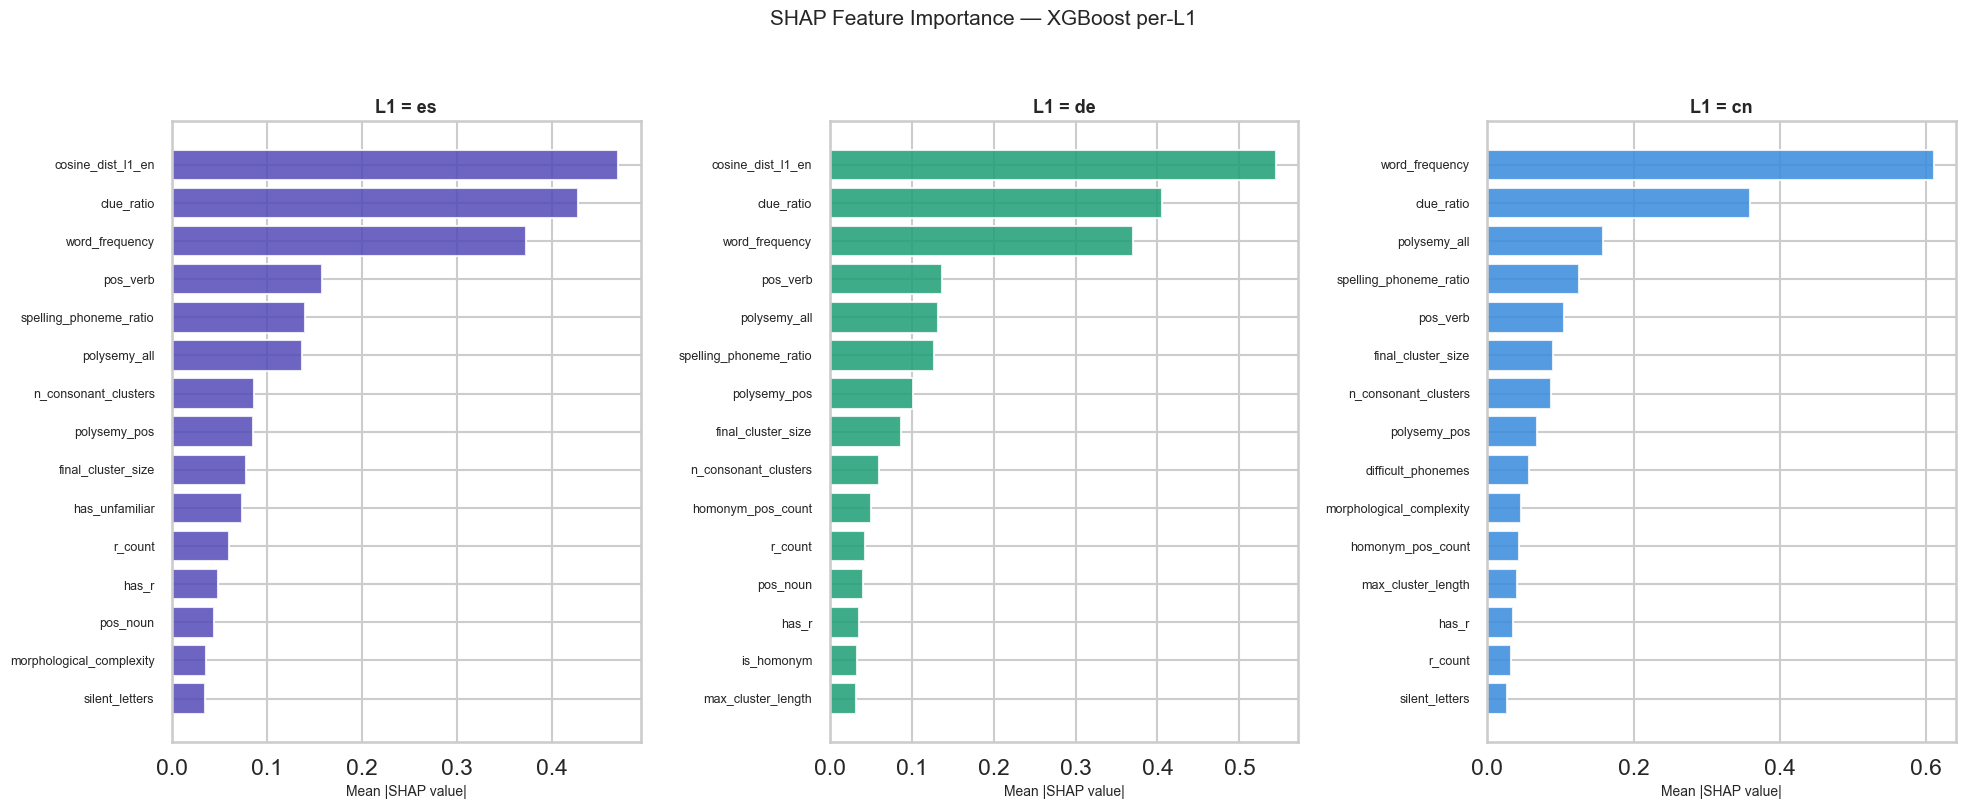

SHAP plot guardado en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features/shap_importance_per_l1.png

--- SHAP Beeswarm: L1 = es ---


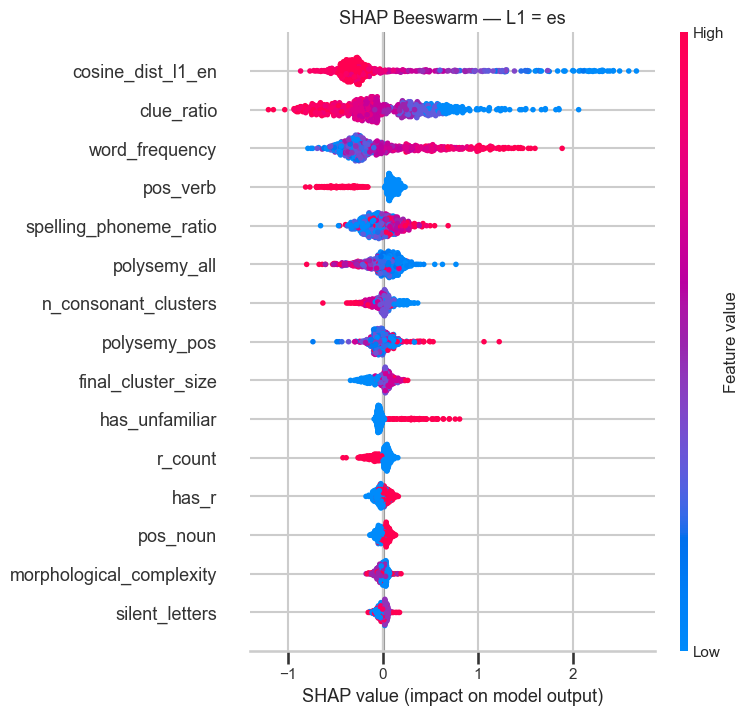


--- SHAP Beeswarm: L1 = de ---


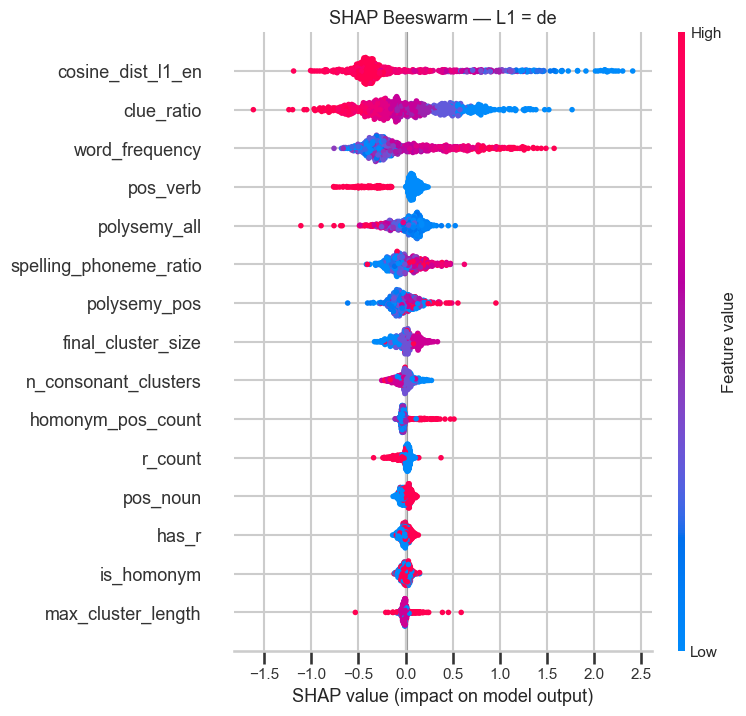


--- SHAP Beeswarm: L1 = cn ---


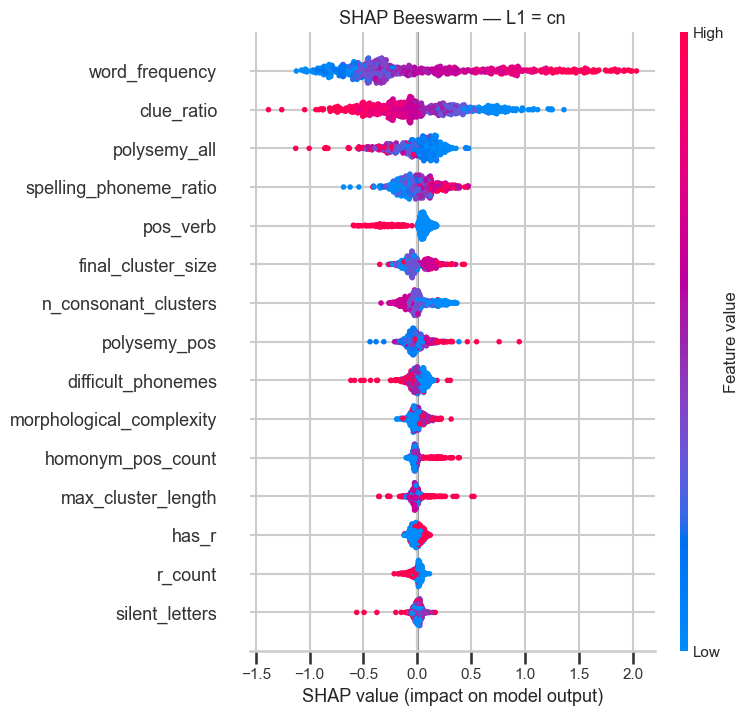


═════════════════════════════════════════════════════════════════
RESUMEN FASE 2.1
═════════════════════════════════════════════════════════════════

Modelos entrenados:
  - 3 XGBoost per-L1 (es, de, cn)
  - 1 XGBoost joint

Predicciones guardadas en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\predictions
Resultados guardados en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\results/xgboost_results_dev.csv
SHAP plots guardados en: C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features

Nota: estas métricas son el piso. El transformer + features
debería superar significativamente estos números.
═════════════════════════════════════════════════════════════════


In [13]:
"""
═══════════════════════════════════════════════════════════════
FASE 2.1 — Modelo Tabular (XGBoost) + Explicabilidad SHAP
═══════════════════════════════════════════════════════════════
Evalúa por L1 individual (es, de, cn).
Métricas: RMSE y Pearson r (como la convocatoria BEA 2026).
 
Requiere: train_final, dev_final (DataFrames de la fase 1.3)
          FEATURE_COLS_FINAL, POS_DUMMY_COLS, L1_DUMMY_COLS
Instalar: pip install xgboost shap
"""
 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
 
# ─────────────────────────────────────────────────────────
# 0. CONFIGURACIÓN
# ─────────────────────────────────────────────────────────
 
FEATURES_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\data\features"
RESULTS_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\results"
PREDICTIONS_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st\predictions"
 
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
 
TARGET = "GLMM_score"
L1S = ["es", "de", "cn"]
 
FEATURE_COLS_FINAL = [
    "clue_ratio",
    "polysemy_pos",
    "is_homonym",
    "n_consonant_clusters",
    "r_count",
    "has_r",
    "silent_letters",
    "difficult_phonemes",
    "word_frequency",
    "polysemy_all",
    "homonym_pos_count",
    "max_cluster_length",
    "spelling_phoneme_ratio",
    "has_unfamiliar",
    "cosine_dist_l1_en",
    "morphological_complexity",
    "final_cluster_size",
]
 
# POS dummies que existen en AMBOS datasets
POS_DUMMY_COLS = [c for c in train_final.columns 
                  if c.startswith("pos_") and c in dev_final.columns]
L1_DUMMY_COLS = [c for c in train_final.columns 
                 if c.startswith("l1_") and c in dev_final.columns]
 
# Para modelo por L1: features + POS dummies (no necesita L1 dummies)
FEATURES_PER_L1 = FEATURE_COLS_FINAL + POS_DUMMY_COLS
 
# Para modelo joint: features + POS + L1 dummies
FEATURES_JOINT = FEATURE_COLS_FINAL + POS_DUMMY_COLS + L1_DUMMY_COLS
 
# ─────────────────────────────────────────────────────────
# 1. MÉTRICAS (igual que evaluate.py del shared task)
# ─────────────────────────────────────────────────────────
 
def evaluate_predictions(y_true, y_pred):
    """RMSE y Pearson r — mismas métricas que BEA 2026."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r = pearsonr(y_true, y_pred)[0]
    return {"rmse": round(rmse, 4), "pearson": round(r, 4)}
 
 
# ─────────────────────────────────────────────────────────
# 2. ENTRENAR XGBOOST POR L1 INDIVIDUAL
# ─────────────────────────────────────────────────────────
 
from xgboost import XGBRegressor
 
# Hiperparámetros razonables para ~6k muestras por L1
XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "min_child_weight": 3,
    "random_state": 42,
    "n_jobs": -1,
}
 
print("=" * 65)
print("FASE 2.1 — XGBoost por L1 individual")
print("=" * 65)
 
results_per_l1 = []
models_per_l1 = {}
 
for l1 in L1S:
    # Filtrar por L1
    tr = train_final[train_final["L1"] == l1].copy()
    dv = dev_final[dev_final["L1"] == l1].copy()
 
    X_train = tr[FEATURES_PER_L1]
    y_train = tr[TARGET]
    X_dev = dv[FEATURES_PER_L1]
    y_dev = dv[TARGET]
 
    # Entrenar
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        verbose=False,
    )
 
    # Predecir
    preds = model.predict(X_dev)
 
    # Evaluar
    metrics = evaluate_predictions(y_dev.values, preds)
    metrics["L1"] = l1
    metrics["model"] = "XGBoost (per-L1)"
    metrics["n_train"] = len(tr)
    metrics["n_dev"] = len(dv)
    results_per_l1.append(metrics)
    models_per_l1[l1] = model
 
    # Guardar predicciones en formato BEA 2026
    pred_df = pd.DataFrame({
        "item_id": dv["item_id"].values,
        "prediction": preds,
    })
    pred_path = os.path.join(PREDICTIONS_DIR, f"xgboost_per_l1_{l1}_preds.csv")
    pred_df.to_csv(pred_path, index=False)
 
    print(f"\n  L1={l1}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}  "
          f"(train={len(tr)}, dev={len(dv)})")
 
# ─────────────────────────────────────────────────────────
# 3. ENTRENAR XGBOOST JOINT (todos los L1s juntos)
# ─────────────────────────────────────────────────────────
 
print(f"\n{'─' * 65}")
print("XGBoost JOINT (3 L1s juntos)")
print(f"{'─' * 65}")
 
X_train_joint = train_final[FEATURES_JOINT]
y_train_joint = train_final[TARGET]
 
model_joint = XGBRegressor(**XGB_PARAMS)
model_joint.fit(
    X_train_joint, y_train_joint,
    eval_set=[(dev_final[FEATURES_JOINT], dev_final[TARGET])],
    verbose=False,
)
 
results_joint = []
for l1 in L1S:
    dv = dev_final[dev_final["L1"] == l1]
    X_dev = dv[FEATURES_JOINT]
    y_dev = dv[TARGET]
    preds = model_joint.predict(X_dev)
    metrics = evaluate_predictions(y_dev.values, preds)
    metrics["L1"] = l1
    metrics["model"] = "XGBoost (joint)"
    results_joint.append(metrics)
 
    # Guardar predicciones
    pred_df = pd.DataFrame({
        "item_id": dv["item_id"].values,
        "prediction": preds,
    })
    pred_path = os.path.join(PREDICTIONS_DIR, f"xgboost_joint_{l1}_preds.csv")
    pred_df.to_csv(pred_path, index=False)
 
    print(f"  L1={l1}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")
 
# ─────────────────────────────────────────────────────────
# 4. TABLA COMPARATIVA vs BASELINES OFICIALES
# ─────────────────────────────────────────────────────────
 
BASELINES_OPEN = {"es": {"rmse": 1.206, "pearson": 0.787},
                  "de": {"rmse": 1.149, "pearson": 0.800},
                  "cn": {"rmse": 1.021, "pearson": 0.804}}
BASELINES_CLOSED = {"es": {"rmse": 1.357, "pearson": 0.748},
                    "de": {"rmse": 1.328, "pearson": 0.753},
                    "cn": {"rmse": 1.175, "pearson": 0.736}}

all_results = results_per_l1 + results_joint
results_df = pd.DataFrame(all_results)

for l1 in L1S:
    results_df.loc[len(results_df)] = {
        "L1": l1, "model": "Baseline open (XLM-R base)",
        "rmse": BASELINES_OPEN[l1]["rmse"], "pearson": BASELINES_OPEN[l1]["pearson"],
    }
    results_df.loc[len(results_df)] = {
        "L1": l1, "model": "Baseline closed (XLM-R base)",
        "rmse": BASELINES_CLOSED[l1]["rmse"], "pearson": BASELINES_CLOSED[l1]["pearson"],
    }
 
print(f"\n{'═' * 65}")
print("COMPARATIVA COMPLETA (dev)")
print(f"{'═' * 65}")
 
for l1 in L1S:
    print(f"\n  L1 = {l1}")
    subset = results_df[results_df["L1"] == l1][["model", "rmse", "pearson"]].reset_index(drop=True)
    display(subset.sort_values("rmse"))
 
# Guardar resultados
results_df.to_csv(os.path.join(RESULTS_DIR, "xgboost_results_dev.csv"), index=False)
 
# ─────────────────────────────────────────────────────────
# 5. SHAP — EXPLICABILIDAD POR L1
# ─────────────────────────────────────────────────────────
 
import shap
 
print(f"\n{'═' * 65}")
print("SHAP — Feature importance por L1")
print(f"{'═' * 65}")
 
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
 
for idx, l1 in enumerate(L1S):
    model = models_per_l1[l1]
    dv = dev_final[dev_final["L1"] == l1]
    X_dev = dv[FEATURES_PER_L1]
 
    # SHAP TreeExplainer (rápido para XGBoost)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_dev)
 
    # Mean absolute SHAP por feature
    shap_importance = pd.DataFrame({
        "feature": FEATURES_PER_L1,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=True)
 
    # Barplot
    ax = axes[idx]
    top_n = 15  # top 15 features
    plot_data = shap_importance.tail(top_n)
    ax.barh(
        plot_data["feature"],
        plot_data["mean_abs_shap"],
        color=["#534AB7", "#1D9E75", "#378ADD"][idx],
        alpha=0.85,
    )
    ax.set_title(f"L1 = {l1}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean |SHAP value|", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
 
plt.suptitle("SHAP Feature Importance — XGBoost per-L1", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, "shap_importance_per_l1.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"SHAP plot guardado en: {FEATURES_DIR}/shap_importance_per_l1.png")
 
# ─────────────────────────────────────────────────────────
# 6. SHAP BEESWARM POR L1 (distribución detallada)
# ─────────────────────────────────────────────────────────
 
for l1 in L1S:
    model = models_per_l1[l1]
    dv = dev_final[dev_final["L1"] == l1]
    X_dev = dv[FEATURES_PER_L1]
 
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_dev)
 
    print(f"\n--- SHAP Beeswarm: L1 = {l1} ---")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_dev, show=False, max_display=15)
    plt.title(f"SHAP Beeswarm — L1 = {l1}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FEATURES_DIR, f"shap_beeswarm_{l1}.png"), dpi=150, bbox_inches="tight")
    plt.show()
 
# ─────────────────────────────────────────────────────────
# 7. RESUMEN FINAL
# ─────────────────────────────────────────────────────────
 
print(f"\n{'═' * 65}")
print("RESUMEN FASE 2.1")
print(f"{'═' * 65}")
print(f"\nModelos entrenados:")
print(f"  - 3 XGBoost per-L1 (es, de, cn)")
print(f"  - 1 XGBoost joint")
print(f"\nPredicciones guardadas en: {PREDICTIONS_DIR}")
print(f"Resultados guardados en: {RESULTS_DIR}/xgboost_results_dev.csv")
print(f"SHAP plots guardados en: {FEATURES_DIR}")
print(f"\nNota: estas métricas son el piso. El transformer + features")
print(f"debería superar significativamente estos números.")
print(f"{'═' * 65}")

In [14]:
"""
CHUNK 1 — Imports y setup
"""
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

Device: cpu


In [21]:
"""
CHUNK 2 — Configuración
"""
BASE_DIR = r"C:\Users\adria\Documents\Doctorado\british_council\bea2026st"
FEATURES_DIR = os.path.join(BASE_DIR, "data", "features")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
PREDICTIONS_DIR = os.path.join(BASE_DIR, "predictions")
MODELS_DIR = os.path.join(BASE_DIR, "models")

for d in [RESULTS_DIR, PREDICTIONS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

MODEL_NAME = "xlm-roberta-large"
MAX_LENGTH = 64          # 128 para prueba rápida, 256 para entrenamiento real
SEED = 42
L1S = ["es", "de", "cn"]
TARGET = "GLMM_score"

HPARAMS = {
    "batch_size": 8,
    "gradient_accumulation": 4,   # effective batch = 32
    "learning_rate": .005,
    "weight_decay": 0.1,
    "warmup_ratio": 0.1,
    "epochs": 1,                  # 2 para prueba rápida, 5 para real
    "max_grad_norm": 1.0,
}

FEATURE_COLS_FINAL = [
    "clue_ratio", "polysemy_pos", "is_homonym", "n_consonant_clusters",
    "r_count", "has_r", "silent_letters", "difficult_phonemes",
    "word_frequency", "polysemy_all", "homonym_pos_count",
    "max_cluster_length", "spelling_phoneme_ratio", "has_unfamiliar",
    "cosine_dist_l1_en", "morphological_complexity", "final_cluster_size",
]

COMPONENT_ORDER = ["L1_source_word", "L1_context", "en_target_clue", "en_target_word"]

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Model: {MODEL_NAME}")
print(f"MAX_LENGTH: {MAX_LENGTH}")
print(f"Epochs: {HPARAMS['epochs']}")
print(f"Effective batch: {HPARAMS['batch_size'] * HPARAMS['gradient_accumulation']}")

Model: xlm-roberta-large
MAX_LENGTH: 64
Epochs: 1
Effective batch: 32


In [22]:
"""
CHUNK 3 — Cargar datos
"""
train_df = pd.read_csv(os.path.join(FEATURES_DIR, "train_features_final.csv"))
dev_df = pd.read_csv(os.path.join(FEATURES_DIR, "dev_features_final.csv"))

print(f"Train original: {train_df.shape}")
print(f"Dev:            {dev_df.shape}")
print(f"Columnas: {list(train_df.columns)}")

# ── FAST MODE: reducir train para prueba rápida ──
# Cambiar a False cuando entrenes en serio
FAST_MODE = True

if FAST_MODE:
    samples = []
    for l1_val in ["es", "de", "cn"]:
        subset = train_df[train_df["L1"] == l1_val]
        n = min(1000, len(subset))
        samples.append(subset.sample(n=n, random_state=42))
    train_df = pd.concat(samples, ignore_index=True)
    print(f"\n⚡ FAST MODE ON: train reducido a {len(train_df)} filas")

print(f"\nTrain final: {train_df.shape}")
print(f"L1s en train: {train_df['L1'].value_counts().to_dict()}")
print(f"L1s en dev:   {dev_df['L1'].value_counts().to_dict()}")

Train original: (18273, 38)
Dev:            (2031, 37)
Columnas: ['item_id', 'L1', 'en_target_word', 'en_target_pos', 'en_target_clue', 'L1_source_word', 'L1_context', 'GLMM_score', 'split', 'clue_ratio', 'polysemy_pos', 'is_homonym', 'n_consonant_clusters', 'r_count', 'has_r', 'silent_letters', 'difficult_phonemes', 'word_frequency', 'polysemy_all', 'homonym_pos_count', 'max_cluster_length', 'spelling_phoneme_ratio', 'has_unfamiliar', 'cosine_dist_l1_en', 'morphological_complexity', 'final_cluster_size', 'pos_adjective', 'pos_adverb', 'pos_determiner', 'pos_misc', 'pos_not-no', 'pos_noun', 'pos_number', 'pos_preposition', 'pos_verb', 'l1_cn', 'l1_de', 'l1_es']

⚡ FAST MODE ON: train reducido a 3000 filas

Train final: (3000, 38)
L1s en train: {'es': 1000, 'de': 1000, 'cn': 1000}
L1s en dev:   {'es': 677, 'de': 677, 'cn': 677}


In [23]:
"""
CHUNK 4 — Dataset y funciones de evaluación
"""

def build_input_text(row):
    """Concatena campos del item — mismo orden que el baseline oficial."""
    parts = [str(row[col]) for col in COMPONENT_ORDER]
    return " ".join(parts)


class VocabDifficultyDataset(Dataset):
    """Dataset para transformer + features tabulares opcionales."""

    def __init__(self, df, tokenizer, feature_cols=None, max_length=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.feature_cols = feature_cols

        self.texts = [build_input_text(row) for _, row in self.df.iterrows()]
        self.labels = self.df[TARGET].values.astype(np.float32)
        self.item_ids = self.df["item_id"].values

        if self.feature_cols:
            self.features = self.df[self.feature_cols].values.astype(np.float32)
        else:
            self.features = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float32),
            "item_id": self.item_ids[idx],
        }
        if self.features is not None:
            item["tabular_features"] = torch.tensor(
                self.features[idx], dtype=torch.float32
            )
        return item


def evaluate_predictions(y_true, y_pred):
    """RMSE y Pearson r — métricas BEA 2026."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r = pearsonr(y_true, y_pred)[0]
    return {"rmse": round(rmse, 4), "pearson": round(r, 4)}


print("Dataset y evaluación definidos.")

Dataset y evaluación definidos.


In [24]:
"""
CHUNK 5 — Arquitectura del modelo
"""

class XLMRRegressor(nn.Module):
    """
    XLM-R con cabeza de regresión.
    - transformer_only: [CLS] → Linear → score
    - hybrid:           [CLS] + features → MLP → score
    """

    def __init__(self, model_name, n_tabular_features=0, dropout=0.1):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden_size = self.transformer.config.hidden_size  # 1024 for large
        self.n_tabular_features = n_tabular_features

        total_input = hidden_size + n_tabular_features

        if n_tabular_features > 0:
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(total_input, 256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, 1),
            )
        else:
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden_size, 1),
            )

    def forward(self, input_ids, attention_mask, tabular_features=None):
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        cls_output = outputs.last_hidden_state[:, 0, :]

        if self.n_tabular_features > 0 and tabular_features is not None:
            combined = torch.cat([cls_output, tabular_features], dim=1)
            return self.head(combined).squeeze(-1)
        else:
            return self.head(cls_output).squeeze(-1)


print("Arquitectura definida:")
print("  - transformer_only: [CLS](1024) → Dropout → Linear(1024,1)")
print(f"  - hybrid: [CLS](1024) + features({len(FEATURE_COLS_FINAL)}) → MLP → Linear(256,1)")

Arquitectura definida:
  - transformer_only: [CLS](1024) → Dropout → Linear(1024,1)
  - hybrid: [CLS](1024) + features(17) → MLP → Linear(256,1)


In [25]:
"""
CHUNK 6 — Training loop (fp16) y función de predicción
"""

def train_model(model, train_loader, dev_loader, hparams, device, model_name_tag):
    """Entrena con mixed precision (fp16) y early stopping en RMSE."""

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hparams["learning_rate"],
        weight_decay=hparams["weight_decay"],
    )

    total_steps = (len(train_loader) * hparams["epochs"]) // hparams["gradient_accumulation"]
    warmup_steps = int(total_steps * hparams["warmup_ratio"])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    loss_fn = nn.MSELoss()
    scaler = GradScaler()
    best_rmse = float("inf")
    best_state = None
    history = []

    for epoch in range(hparams["epochs"]):
        # --- Train ---
        model.train()
        train_losses = []
        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{hparams['epochs']} [train]")
        for step, batch in enumerate(pbar):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            tabular = batch.get("tabular_features")
            if tabular is not None:
                tabular = tabular.to(device)

            with autocast():
                preds = model(input_ids, attention_mask, tabular)
                loss = loss_fn(preds, labels) / hparams["gradient_accumulation"]

            scaler.scale(loss).backward()

            if (step + 1) % hparams["gradient_accumulation"] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), hparams["max_grad_norm"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            train_losses.append(loss.item() * hparams["gradient_accumulation"])
            pbar.set_postfix({"loss": f"{np.mean(train_losses[-50:]):.4f}"})

        # --- Evaluate ---
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(dev_loader, desc=f"Epoch {epoch+1}/{hparams['epochs']} [eval]"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                tabular = batch.get("tabular_features")
                if tabular is not None:
                    tabular = tabular.to(device)

                with autocast():
                    preds = model(input_ids, attention_mask, tabular)

                all_preds.extend(preds.float().cpu().numpy())
                all_labels.extend(batch["label"].numpy())

        metrics = evaluate_predictions(np.array(all_labels), np.array(all_preds))
        metrics["epoch"] = epoch + 1
        metrics["train_loss"] = round(np.mean(train_losses), 4)
        history.append(metrics)

        print(f"  → Epoch {epoch+1}: RMSE={metrics['rmse']:.4f}  "
              f"Pearson={metrics['pearson']:.4f}  Loss={metrics['train_loss']:.4f}")

        if metrics["rmse"] < best_rmse:
            best_rmse = metrics["rmse"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ Best model (RMSE={best_rmse:.4f})")

    model.load_state_dict(best_state)
    model.to(device)
    return model, history


def predict(model, loader, device):
    """Genera predicciones."""
    model.eval()
    all_preds = []
    all_ids = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            tabular = batch.get("tabular_features")
            if tabular is not None:
                tabular = tabular.to(device)

            with autocast():
                preds = model(input_ids, attention_mask, tabular)

            all_preds.extend(preds.float().cpu().numpy())
            all_ids.extend(batch["item_id"].numpy())

    return np.array(all_ids), np.array(all_preds)


print("Training loop y predict definidos (fp16 mixed precision).")

Training loop y predict definidos (fp16 mixed precision).


In [26]:
"""
CHUNK 7 — Fase 2.2: XLM-R Large SOLO (por L1 individual)
"""

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

results_transformer = []

for l1 in L1S:
    print(f"\n{'═' * 60}")
    print(f"ENTRENANDO XLM-R Large SOLO — L1 = {l1}")
    print(f"{'═' * 60}")

    tr = train_df[train_df["L1"] == l1]
    dv = dev_df[dev_df["L1"] == l1]

    train_ds = VocabDifficultyDataset(tr, tokenizer, feature_cols=None, max_length=MAX_LENGTH)
    dev_ds = VocabDifficultyDataset(dv, tokenizer, feature_cols=None, max_length=MAX_LENGTH)

    train_loader = DataLoader(
        train_ds, batch_size=HPARAMS["batch_size"], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    dev_loader = DataLoader(
        dev_ds, batch_size=HPARAMS["batch_size"] * 2, shuffle=False,
        num_workers=0, pin_memory=True,
    )

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Train: {len(tr)}, Dev: {len(dv)}")

    model, history = train_model(
        model, train_loader, dev_loader, HPARAMS, DEVICE,
        model_name_tag=f"xlmr_large_{l1}",
    )

    # Predicciones finales
    item_ids, preds = predict(model, dev_loader, DEVICE)
    dv_indexed = dv.set_index("item_id")
    y_true = dv_indexed.loc[item_ids][TARGET].values
    metrics = evaluate_predictions(y_true, preds)
    metrics["L1"] = l1
    metrics["model"] = "XLM-R Large (solo)"
    results_transformer.append(metrics)

    print(f"\n  FINAL L1={l1}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")

    # Guardar predicciones formato BEA 2026
    pred_df = pd.DataFrame({"item_id": item_ids.astype(int), "prediction": preds})
    pred_df.to_csv(os.path.join(PREDICTIONS_DIR, f"xlmr_large_solo_{l1}_preds.csv"), index=False)

    # Guardar modelo
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"xlmr_large_solo_{l1}.pt"))

    del model
    torch.cuda.empty_cache()

print(f"\n{'═' * 60}")
print("RESULTADOS XLM-R Large (solo) por L1:")
print(f"{'═' * 60}")
display(pd.DataFrame(results_transformer))

Tokenizer loaded: xlm-roberta-large

════════════════════════════════════════════════════════════
ENTRENANDO XLM-R Large SOLO — L1 = es
════════════════════════════════════════════════════════════


Loading weights: 100%|██████████| 391/391 [00:01<00:00, 209.59it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Params: 559,891,457
  Train: 1000, Dev: 677


Epoch 1/1 [train]:   9%|▉         | 11/125 [06:53<1:11:29, 37.63s/it, loss=7.4066]


KeyboardInterrupt: 

In [ ]:
"""
CHUNK 7 — Fase 2.2: XLM-R Large SOLO (por L1 individual)
"""

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

results_transformer = []

for l1 in L1S:
    print(f"\n{'═' * 60}")
    print(f"ENTRENANDO XLM-R Large SOLO — L1 = {l1}")
    print(f"{'═' * 60}")

    tr = train_df[train_df["L1"] == l1]
    dv = dev_df[dev_df["L1"] == l1]

    train_ds = VocabDifficultyDataset(tr, tokenizer, feature_cols=None, max_length=MAX_LENGTH)
    dev_ds = VocabDifficultyDataset(dv, tokenizer, feature_cols=None, max_length=MAX_LENGTH)

    train_loader = DataLoader(
        train_ds, batch_size=HPARAMS["batch_size"], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    dev_loader = DataLoader(
        dev_ds, batch_size=HPARAMS["batch_size"] * 2, shuffle=False,
        num_workers=0, pin_memory=True,
    )

    model = XLMRRegressor(MODEL_NAME, n_tabular_features=0).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Train: {len(tr)}, Dev: {len(dv)}")

    model, history = train_model(
        model, train_loader, dev_loader, HPARAMS, DEVICE,
        model_name_tag=f"xlmr_large_{l1}",
    )

    # Predicciones finales
    item_ids, preds = predict(model, dev_loader, DEVICE)
    dv_indexed = dv.set_index("item_id")
    y_true = dv_indexed.loc[item_ids][TARGET].values
    metrics = evaluate_predictions(y_true, preds)
    metrics["L1"] = l1
    metrics["model"] = "XLM-R Large (solo)"
    results_transformer.append(metrics)

    print(f"\n  FINAL L1={l1}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")

    # Guardar predicciones formato BEA 2026
    pred_df = pd.DataFrame({"item_id": item_ids.astype(int), "prediction": preds})
    pred_df.to_csv(os.path.join(PREDICTIONS_DIR, f"xlmr_large_solo_{l1}_preds.csv"), index=False)

    # Guardar modelo
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"xlmr_large_solo_{l1}.pt"))

    del model
    torch.cuda.empty_cache()

print(f"\n{'═' * 60}")
print("RESULTADOS XLM-R Large (solo) por L1:")
print(f"{'═' * 60}")
display(pd.DataFrame(results_transformer))

In [ ]:
"""
CHUNK 9 — Fase 2.3: Modelo HÍBRIDO (XLM-R Large + Features)
"""

results_hybrid = []

for l1 in L1S:
    print(f"\n{'═' * 60}")
    print(f"ENTRENANDO HÍBRIDO — L1 = {l1}")
    print(f"{'═' * 60}")

    tr = train_df[train_df["L1"] == l1]
    dv = dev_df[dev_df["L1"] == l1]

    train_ds = VocabDifficultyDataset(
        tr, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH
    )
    dev_ds = VocabDifficultyDataset(
        dv, tokenizer, feature_cols=available_features, max_length=MAX_LENGTH
    )

    train_loader = DataLoader(
        train_ds, batch_size=HPARAMS["batch_size"], shuffle=True,
        num_workers=0, pin_memory=True,
    )
    dev_loader = DataLoader(
        dev_ds, batch_size=HPARAMS["batch_size"] * 2, shuffle=False,
        num_workers=0, pin_memory=True,
    )

    model = XLMRRegressor(
        MODEL_NAME,
        n_tabular_features=len(available_features),
    ).to(DEVICE)
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Tabular features: {len(available_features)}")
    print(f"  Train: {len(tr)}, Dev: {len(dv)}")

    model, history = train_model(
        model, train_loader, dev_loader, HPARAMS, DEVICE,
        model_name_tag=f"hybrid_{l1}",
    )

    # Predicciones finales
    item_ids, preds = predict(model, dev_loader, DEVICE)
    dv_indexed = dv.set_index("item_id")
    y_true = dv_indexed.loc[item_ids][TARGET].values
    metrics = evaluate_predictions(y_true, preds)
    metrics["L1"] = l1
    metrics["model"] = "Hybrid (XLM-R Large + features)"
    results_hybrid.append(metrics)

    print(f"\n  FINAL L1={l1}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")

    # Guardar predicciones
    pred_df = pd.DataFrame({"item_id": item_ids.astype(int), "prediction": preds})
    pred_df.to_csv(os.path.join(PREDICTIONS_DIR, f"hybrid_{l1}_preds.csv"), index=False)

    # Guardar modelo
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"hybrid_{l1}.pt"))

    del model
    torch.cuda.empty_cache()

print(f"\n{'═' * 60}")
print("RESULTADOS HÍBRIDO por L1:")
print(f"{'═' * 60}")
display(pd.DataFrame(results_hybrid))

In [ ]:
"""
CHUNK 10 — Ensemble + Tabla comparativa final
"""

# ── ENSEMBLE ──
results_ensemble = []

for l1 in L1S:
    print(f"\n--- Ensemble L1 = {l1} ---")

    trans_path = os.path.join(PREDICTIONS_DIR, f"xlmr_large_solo_{l1}_preds.csv")
    xgb_path = os.path.join(PREDICTIONS_DIR, f"xgboost_per_l1_{l1}_preds.csv")

    if not os.path.exists(trans_path):
        print(f"  ⚠️  No se encontró {trans_path}, saltando")
        continue
    if not os.path.exists(xgb_path):
        print(f"  ⚠️  No se encontró {xgb_path}, saltando")
        continue

    trans_preds = pd.read_csv(trans_path)
    xgb_preds = pd.read_csv(xgb_path)

    merged = trans_preds.merge(xgb_preds, on="item_id", suffixes=("_trans", "_xgb"))
    dv = dev_df[dev_df["L1"] == l1]
    merged = merged.merge(dv[["item_id", TARGET]], on="item_id")

    best_alpha = 0
    best_rmse = float("inf")

    for alpha in np.arange(0.0, 1.05, 0.05):
        ensemble_pred = alpha * merged["prediction_trans"] + (1 - alpha) * merged["prediction_xgb"]
        rmse = np.sqrt(mean_squared_error(merged[TARGET], ensemble_pred))
        if rmse < best_rmse:
            best_rmse = rmse
            best_alpha = alpha

    final_pred = best_alpha * merged["prediction_trans"] + (1 - best_alpha) * merged["prediction_xgb"]
    metrics = evaluate_predictions(merged[TARGET].values, final_pred.values)
    metrics["L1"] = l1
    metrics["model"] = f"Ensemble (α={best_alpha:.2f})"
    results_ensemble.append(metrics)

    print(f"  Best α={best_alpha:.2f}: RMSE={metrics['rmse']:.4f}  Pearson={metrics['pearson']:.4f}")

    pred_df = pd.DataFrame({"item_id": merged["item_id"], "prediction": final_pred})
    pred_df.to_csv(os.path.join(PREDICTIONS_DIR, f"ensemble_{l1}_preds.csv"), index=False)

# ── TABLA COMPARATIVA FINAL ──
baselines = []
for l1 in L1S:
    baselines.append({
        "L1": l1, "model": "Baseline open (XLM-R base)",
        "rmse": {"es": 1.206, "de": 1.149, "cn": 1.021}[l1],
        "pearson": {"es": 0.787, "de": 0.800, "cn": 0.804}[l1],
    })
    baselines.append({
        "L1": l1, "model": "Baseline closed (XLM-R base)",
        "rmse": {"es": 1.357, "de": 1.328, "cn": 1.175}[l1],
        "pearson": {"es": 0.748, "de": 0.753, "cn": 0.736}[l1],
    })

all_results = baselines + results_transformer + results_hybrid + results_ensemble
final_df = pd.DataFrame(all_results)[["L1", "model", "rmse", "pearson"]]

print(f"\n{'═' * 70}")
print("TABLA COMPARATIVA FINAL (dev)")
print(f"{'═' * 70}")

for l1 in L1S:
    print(f"\n  L1 = {l1}")
    subset = final_df[final_df["L1"] == l1].sort_values("rmse").reset_index(drop=True)
    display(subset)

final_df.to_csv(os.path.join(RESULTS_DIR, "all_results_comparison.csv"), index=False)
print(f"\nResultados guardados en: {RESULTS_DIR}/all_results_comparison.csv")

## 4. Main model: a single XLM-RoBERTa-large

We now evaluate the main model.

The chosen integration is the simplest to explain and to port to Colab:

- convert the features into short text tags
- prepend them to the original input
- use a single transformer, `xlm-roberta-large`

If the result is worse than the official baseline, the correct reading is not that the features are useless, but that this particular form of integration is not working well.

,L1,rmse,pearson,model_label
2,cn,1.021,0.804,Official baseline
5,cn,1.429,0.541,Features only (RF)
8,cn,1.678,0.401,XLM-R large + features
1,de,1.149,0.800,Official baseline
4,de,1.671,0.414,Features only (RF)
7,de,1.817,0.353,XLM-R large + features
0,es,1.206,0.787,Official baseline
3,es,1.741,0.419,Features only (RF)
6,es,1.904,0.348,XLM-R large + features


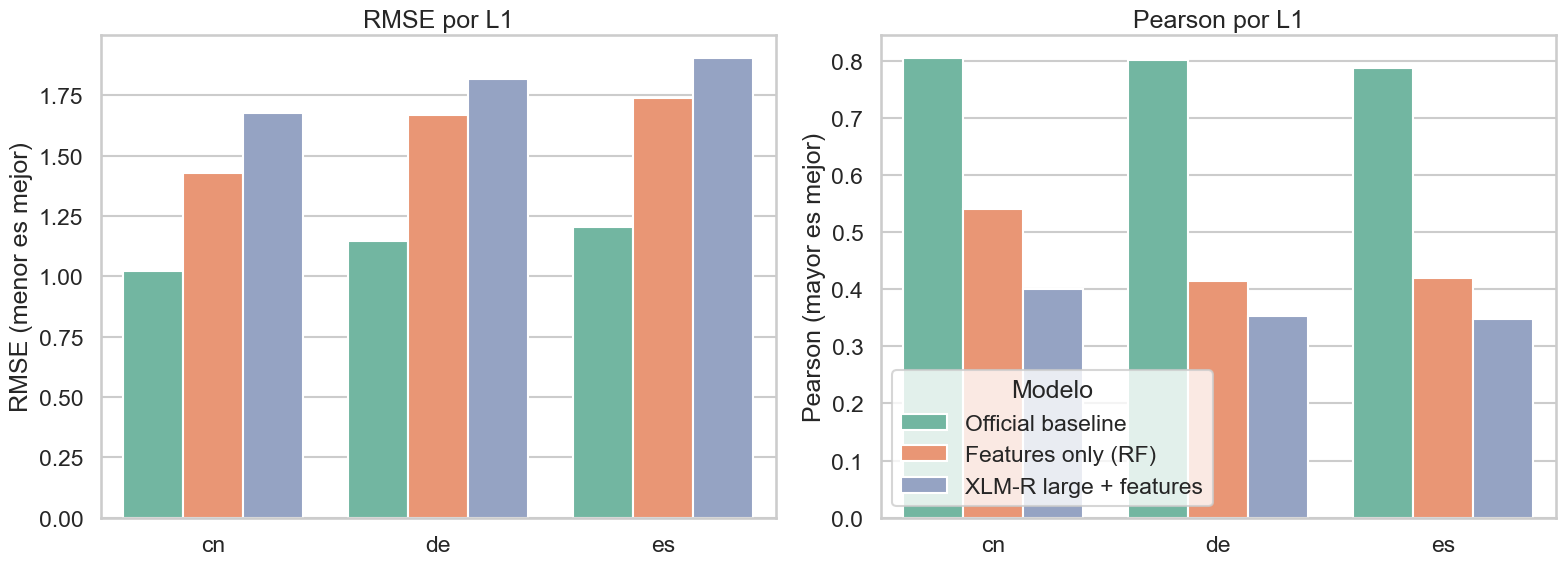

Resumen rapido:
- Features only | L1=es | delta RMSE vs baseline: -0.535
- Features only | L1=de | delta RMSE vs baseline: -0.522
- Features only | L1=cn | delta RMSE vs baseline: -0.408
- Transformer+features | L1=es | delta RMSE vs baseline: -0.698
- Transformer+features | L1=de | delta RMSE vs baseline: -0.669
- Transformer+features | L1=cn | delta RMSE vs baseline: -0.657


In [ ]:
# ==============================================================================
# Comparación final: todos los métodos, con tabla individual por idioma
# ==============================================================================

all_dfs = [baseline_results, tabular_results, transformer_results]
if "hybrid_results" in dir() and len(hybrid_results) > 0:
    all_dfs.append(hybrid_results)

comparison_df = pd.concat(all_dfs, ignore_index=True)

model_order = [
    "Official baseline",
    "Features only (RF)",
    "XLM-R large + features (finetuned)",
    "Hybrid global",
    "Hybrid per-L1",
]
existing_cats = [c for c in model_order if c in comparison_df["model_label"].unique()]
comparison_df["model_label"] = pd.Categorical(
    comparison_df["model_label"], categories=existing_cats, ordered=True,
)
comparison_df = comparison_df.sort_values(["L1", "model_label"])

# ── Tabla individual por cada idioma ──────────────────────────────────────────
baseline_lookup = baseline_results.set_index("L1")
l1_names = {"es": "Español (es)", "de": "Alemán (de)", "cn": "Mandarín (cn)"}

for l1 in L1_ORDER:
    sub = comparison_df[comparison_df["L1"] == l1].copy()
    bl_rmse = baseline_lookup.loc[l1, "rmse"]
    bl_pearson = baseline_lookup.loc[l1, "pearson"]
    sub["Δ RMSE"] = bl_rmse - sub["rmse"]
    sub["Δ Pearson"] = sub["pearson"] - bl_pearson
    sub["mejor?"] = sub["Δ RMSE"].apply(lambda x: "✓" if x > 0 else "✗")
    print(f"\n{'='*70}")
    print(f"  {l1_names[l1]}")
    print(f"{'='*70}")
    display(
        sub[["model_label", "rmse", "pearson", "Δ RMSE", "Δ Pearson", "mejor?"]]
        .round(4)
        .reset_index(drop=True)
        .style.set_caption(f"Resultados dev — {l1_names[l1]}")
    )

# ── Gráfica resumen ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=comparison_df, x="L1", y="rmse", hue="model_label", palette="Set2", ax=axes[0])
axes[0].set_title("RMSE por L1 (menor es mejor)")
axes[0].set_ylabel("RMSE")
axes[0].set_xlabel("")

sns.barplot(data=comparison_df, x="L1", y="pearson", hue="model_label", palette="Set2", ax=axes[1])
axes[1].set_title("Pearson por L1 (mayor es mejor)")
axes[1].set_ylabel("Pearson r")
axes[1].set_xlabel("")

handles, labels = axes[1].get_legend_handles_labels()
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
axes[1].legend(handles, labels, title="Modelo", loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## 4b. Hybrid method: frozen transformer embeddings + XGBoost

The idea here differs from serializing features as text:

1. Use `xlm-roberta-large` frozen (no fine-tuning) purely as an embedding extractor.
2. Extract the `[CLS]` vector (1024 dimensions) for each example.
3. Reduce to 128 dimensions with PCA.
4. Concatenate those 128 dimensions with the 25 precomputed linguistic features, yielding a 153-dimensional vector.
5. Train XGBoost on the combined vector.

This answers a different question from the previous section:

> **Does the contextual representation of the transformer, combined with tabular features in a gradient boosting model, outperform the baseline?**

Advantage: no transformer fine-tuning is needed, which is faster and lighter on GPU. Disadvantage: the transformer does not adapt to the domain.

In [ ]:
# ==============================================================================
# 4b. Hybrid: Frozen XLM-RoBERTa-large embeddings + linguistic features + XGBoost
# ==============================================================================
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold

# ── 1. Load pre-computed feature CSVs ──────────────────────────────────────────
FEATURES_DIR = DATA_DIR / "features"
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

LINGUISTIC_FEATURE_COLS = [
    "word_length", "clue_ratio", "polysemy_all", "polysemy_pos", "is_homonym",
    "homonym_pos_count", "n_consonant_clusters", "max_cluster_length", "has_r",
    "r_count", "rhotacism_weighted", "n_phonemes", "silent_letters",
    "spelling_phoneme_ratio", "unfamiliar_letters", "has_unfamiliar",
    "syntactic_difficulty", "cosine_dist_l1_en", "difficult_phonemes",
    "difficult_phoneme_ratio", "difficult_graphemes", "final_cluster_size",
    "word_frequency", "levenshtein_dist", "morphological_complexity",
]

train_feat_full = pd.concat(
    [pd.read_csv(FEATURES_DIR / f"{l1}_train_features.csv") for l1 in L1_ORDER],
    ignore_index=True,
)
dev_feat_full = pd.concat(
    [pd.read_csv(FEATURES_DIR / f"{l1}_dev_features.csv") for l1 in L1_ORDER],
    ignore_index=True,
)
print(f"Train features: {train_feat_full.shape} | Dev features: {dev_feat_full.shape}")

available_ling = [c for c in LINGUISTIC_FEATURE_COLS if c in train_feat_full.columns]
missing_ling = [c for c in LINGUISTIC_FEATURE_COLS if c not in train_feat_full.columns]
if missing_ling:
    print(f"⚠ Missing features (will skip): {missing_ling}")
print(f"Using {len(available_ling)} linguistic features")

# ── 2. Extract [CLS] embeddings ── with disk cache so we only do this ONCE ──────
from transformers import AutoModel

train_emb_path = EMBEDDINGS_DIR / "train_cls_embeddings.npy"
dev_emb_path = EMBEDDINGS_DIR / "dev_cls_embeddings.npy"

def build_text_input(row):
    sep = " </s> "
    return sep.join([
        str(row["L1_source_word"]),
        str(row["L1_context"]),
        str(row["en_target_clue"]),
        str(row["en_target_word"]),
    ])

def extract_cls_embeddings(df, batch_size):
    """Extract [CLS] embeddings from the frozen model."""
    texts = df.apply(build_text_input, axis=1).tolist()
    all_embeddings = []
    n_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        encoded = emb_tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=MAX_LENGTH, return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            outputs = emb_model(**encoded)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
        batch_num = i // batch_size + 1
        if batch_num % 20 == 0 or batch_num == n_batches:
            print(f"  Batch {batch_num}/{n_batches}")
    return np.vstack(all_embeddings)

if train_emb_path.exists() and dev_emb_path.exists():
    print("Cargando embeddings desde caché en disco...")
    train_cls = np.load(train_emb_path)
    dev_cls = np.load(dev_emb_path)
    print(f"  Train: {train_cls.shape} | Dev: {dev_cls.shape}")
else:
    print(f"Extrayendo embeddings con xlm-roberta-large (device={DEVICE})...")
    emb_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large", use_fast=True)
    emb_model = AutoModel.from_pretrained("xlm-roberta-large")
    emb_model.eval()
    emb_model.to(DEVICE)

    print("  Train embeddings...")
    train_cls = extract_cls_embeddings(train_feat_full, batch_size=EMB_BATCH_SIZE)
    np.save(train_emb_path, train_cls)
    print(f"  ✓ Guardado: {train_emb_path} ({train_cls.shape})")

    print("  Dev embeddings...")
    dev_cls = extract_cls_embeddings(dev_feat_full, batch_size=EMB_BATCH_SIZE)
    np.save(dev_emb_path, dev_cls)
    print(f"  ✓ Guardado: {dev_emb_path} ({dev_cls.shape})")

    del emb_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── 3. PCA reduction ─────────────────────────────────────────────────────────────
pca = PCA(n_components=PCA_DIMS, random_state=SEED)
train_pca = pca.fit_transform(train_cls)
dev_pca = pca.transform(dev_cls)
print(f"PCA: {train_cls.shape[1]} → {PCA_DIMS} dims (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

# ── 4. Build combined feature matrices ─────────────────────────────────────────
ling_imputer = SimpleImputer(strategy="median")
X_train_ling = ling_imputer.fit_transform(train_feat_full[available_ling].values)
X_dev_ling = ling_imputer.transform(dev_feat_full[available_ling].values)

X_train_hybrid = np.hstack([train_pca, X_train_ling])
X_dev_hybrid = np.hstack([dev_pca, X_dev_ling])
y_train_hybrid = train_feat_full["GLMM_score"].values
y_dev_hybrid = dev_feat_full["GLMM_score"].values

print(f"Hybrid vector: {PCA_DIMS} PCA + {len(available_ling)} ling = {X_train_hybrid.shape[1]} dims")
print(f"Train: {X_train_hybrid.shape} | Dev: {X_dev_hybrid.shape}")

# ── 5a. Global XGBoost on combined features ──────────────────────────────────
xgb_hybrid = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1,
)
xgb_hybrid.fit(X_train_hybrid, y_train_hybrid, eval_set=[(X_dev_hybrid, y_dev_hybrid)], verbose=False)
hybrid_preds = xgb_hybrid.predict(X_dev_hybrid)

hybrid_results_rows = []
print("\n--- Hybrid Global (PCA embeddings + features → XGBoost) ---")
for l1 in L1_ORDER:
    mask = (dev_feat_full["L1"] == l1).values
    r = rmse(y_dev_hybrid[mask], hybrid_preds[mask])
    p = safe_pearson(hybrid_preds[mask], y_dev_hybrid[mask])
    hybrid_results_rows.append({"L1": l1, "rmse": r, "pearson": p, "model_label": "Hybrid global"})
    print(f"  L1={l1}  RMSE={r:.4f}  Pearson={p:.4f}")

# ── 5b. Per-L1 XGBoost models ───────────────────────────────────────────────
print("\n--- Hybrid Per-L1 ---")
per_l1_hybrid_preds = np.zeros(len(dev_feat_full))
for l1 in L1_ORDER:
    tr_mask = (train_feat_full["L1"] == l1).values
    dv_mask = (dev_feat_full["L1"] == l1).values
    model_l1 = xgb.XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1,
    )
    model_l1.fit(
        X_train_hybrid[tr_mask], y_train_hybrid[tr_mask],
        eval_set=[(X_dev_hybrid[dv_mask], y_dev_hybrid[dv_mask])], verbose=False,
    )
    preds_l1 = model_l1.predict(X_dev_hybrid[dv_mask])
    per_l1_hybrid_preds[dv_mask] = preds_l1
    r = rmse(y_dev_hybrid[dv_mask], preds_l1)
    p = safe_pearson(preds_l1, y_dev_hybrid[dv_mask])
    hybrid_results_rows.append({"L1": l1, "rmse": r, "pearson": p, "model_label": "Hybrid per-L1"})
    print(f"  L1={l1}  RMSE={r:.4f}  Pearson={p:.4f}")

hybrid_results = pd.DataFrame(hybrid_results_rows)
display(hybrid_results.round(3))

# ── 5c. 5-Fold CV (robustness check) ────────────────────────────────────────
print("\n--- 5-Fold CV on Train (Hybrid Global) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rmses, cv_pearsons = [], []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_hybrid)):
    xgb_cv = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1,
    )
    xgb_cv.fit(
        X_train_hybrid[tr_idx], y_train_hybrid[tr_idx],
        eval_set=[(X_train_hybrid[val_idx], y_train_hybrid[val_idx])], verbose=False,
    )
    fold_preds = xgb_cv.predict(X_train_hybrid[val_idx])
    cv_rmses.append(rmse(y_train_hybrid[val_idx], fold_preds))
    cv_pearsons.append(safe_pearson(fold_preds, y_train_hybrid[val_idx]))

print(f"  CV RMSE:    {np.mean(cv_rmses):.4f} ± {np.std(cv_rmses):.4f}")
print(f"  CV Pearson: {np.mean(cv_pearsons):.4f} ± {np.std(cv_pearsons):.4f}")

Train features: (18273, 34) | Dev features: (2031, 34)
Using 25 linguistic features
⚠ No cached embeddings found and running on CPU.
  Extracting on CPU will be VERY slow (~1h for 18k samples).
  Options:
  1. Run this cell in Colab with GPU (recommended)
  2. Wait for CPU extraction (slow but works)
  Proceeding with CPU extraction...


Train features: (18273, 34) | Dev features: (2031, 34)
Using 25 linguistic features
⚠ No cached embeddings found and running on CPU.
  Extracting on CPU will be VERY slow (~1h for 18k samples).
  Options:
  1. Run this cell in Colab with GPU (recommended)
  2. Wait for CPU extraction (slow but works)
  Proceeding with CPU extraction...


Train features: (18273, 34) | Dev features: (2031, 34)
Using 25 linguistic features
⚠ No cached embeddings found and running on CPU.
  Extracting on CPU will be VERY slow (~1h for 18k samples).
  Options:
  1. Run this cell in Colab with GPU (recommended)
  2. Wait for CPU extraction (slow but works)
  Proceeding with CPU extraction...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train features: (18273, 34) | Dev features: (2031, 34)
Using 25 linguistic features
⚠ No cached embeddings found and running on CPU.
  Extracting on CPU will be VERY slow (~1h for 18k samples).
  Options:
  1. Run this cell in Colab with GPU (recommended)
  2. Wait for CPU extraction (slow but works)
  Proceeding with CPU extraction...


XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting train embeddings...


## 5. How to interpret the results

### Three methods, one question

| # | Method | What it measures |
|---|--------|------------------|
| 1 | **Features only (RF)** | Do the linguistic features carry signal of their own for predicting difficulty? |
| 2 | **XLM-R large + features (fine-tuned)** | Does serializing features as text and fine-tuning improve on the baseline? |
| 3 | **Hybrid (embeddings + XGBoost)** | Is combining a frozen contextual representation with tabular features in XGBoost better? |

### Reading the results by case

- If the Hybrid outperforms the baseline, the linguistic features complement the transformer well when combined in a tabular model.
- If the Hybrid ties or loses, the frozen representation does not capture enough domain signal, and the solution requires fine-tuning.
- If Features only (RF) reaches a reasonable Pearson (around 0.4 to 0.5), the features carry real signal but the transformer already subsumes it.
- If the fine-tuned model improves on Colab, the local failure was caused by an old checkpoint that did not match the current input format.

### Running on Google Colab

1. Upload the `bea2026st/` folder to the Colab environment.
2. Set `RUN_TRANSFORMER_TRAINING = True` in the setup cell.
3. Embeddings are cached in `data/embeddings/` and extracted only once.
4. On a T4 GPU the transformer takes about 15 minutes and the embedding extraction about 5 minutes.

### Recommended next step

Run an ablation on the hybrid method:

1. PCA embeddings only (no linguistic features)
2. Linguistic features only (no embeddings)
3. Combined (as currently configured)

This quantifies exactly how much each component contributes.